# Модуль 5. Средства Казначейства, бюджетные средства и ликвидность банковского сектора

Цель ноутбука - проверить готовые processed-датасеты М5, не переписывая backend pipeline, и подготовить методологические рекомендации для будущего `m5_feature_builder.py`.

Что проверяем:
- качество данных: размеры, даты, типы, пропуски, дубли;
- гранулярность источников: daily / monthly / auction-level;
- корректность сборки `m5_dataset.csv`;
- экономический смысл признаков и риск leakage;
- набор признаков, который стоит или не стоит переносить в backend после согласования.

Финальный LSI здесь не считается, dashboard не строится.


In [14]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd

import matplotlib
if "ipykernel" not in sys.modules:
    matplotlib.use("Agg", force=True)
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

sns.set_theme(style="whitegrid", context="notebook")


def find_project_root(start: Path | None = None) -> Path:
    """Находит корень проекта при запуске из корня или из ml/notebooks."""
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "data/processed/m5_dataset.csv").exists() and (candidate / "backend/src").exists():
            return candidate
    raise FileNotFoundError("Не найден корень проекта с data/processed/m5_dataset.csv и backend/src")


PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data" / "processed"

PATHS = {
    "m5": DATA_DIR / "m5_dataset.csv",
    "budget": DATA_DIR / "cbr_budget_funds.csv",
    "liquidity": DATA_DIR / "cbr_liquidity.csv",
    "roskazna": DATA_DIR / "roskazna_treasury_deposits.csv",
}

print(f"Project root: {PROJECT_ROOT}")
for name, path in PATHS.items():
    print(f"{name:10s}: {path}")


Project root: c:\Users\Huawei\python_programming\psb_case
m5        : c:\Users\Huawei\python_programming\psb_case\data\processed\m5_dataset.csv
budget    : c:\Users\Huawei\python_programming\psb_case\data\processed\cbr_budget_funds.csv
liquidity : c:\Users\Huawei\python_programming\psb_case\data\processed\cbr_liquidity.csv
roskazna  : c:\Users\Huawei\python_programming\psb_case\data\processed\roskazna_treasury_deposits.csv


## 1. Загрузка данных

Ноутбук не зависит от текущей рабочей директории: путь к корню проекта определяется по наличию `data/processed/m5_dataset.csv` и `backend/src`.


In [15]:
DATE_FORMAT = "%d-%m-%Y"

m5 = pd.read_csv(PATHS["m5"])
budget = pd.read_csv(PATHS["budget"])
liquidity = pd.read_csv(PATHS["liquidity"])
roskazna = pd.read_csv(PATHS["roskazna"])

frames = {
    "m5_dataset": m5,
    "cbr_budget_funds": budget,
    "cbr_liquidity": liquidity,
    "roskazna_treasury_deposits": roskazna,
}

raw_shapes = {name: df.shape for name, df in frames.items()}

for df, cols in [
    (m5, ["date", "budget_funds_date"]),
    (budget, ["date"]),
    (liquidity, ["date"]),
    (roskazna, ["auction_date", "first_leg_date", "second_leg_date"]),
]:
    for col in cols:
        if col in df.columns:
            df[f"{col}_dt"] = pd.to_datetime(df[col], format=DATE_FORMAT, errors="coerce")

file_report = []
for name, path in PATHS.items():
    df = {
        "m5": m5,
        "budget": budget,
        "liquidity": liquidity,
        "roskazna": roskazna,
    }[name]
    file_report.append({
        "dataset": name,
        "path": str(path.relative_to(PROJECT_ROOT)),
        "exists": path.exists(),
        "size_mb": path.stat().st_size / 1024 / 1024,
        "rows": raw_shapes[{"m5": "m5_dataset", "budget": "cbr_budget_funds", "liquidity": "cbr_liquidity", "roskazna": "roskazna_treasury_deposits"}[name]][0],
        "columns": raw_shapes[{"m5": "m5_dataset", "budget": "cbr_budget_funds", "liquidity": "cbr_liquidity", "roskazna": "roskazna_treasury_deposits"}[name]][1],
    })

file_report = pd.DataFrame(file_report)
display(file_report)


,dataset,path,exists,size_mb,rows,columns
0,m5,data\processed\m5_dataset.csv,True,0.6699,3077,34
1,budget,data\processed\cbr_budget_funds.csv,True,0.0796,513,9
2,liquidity,data\processed\cbr_liquidity.csv,True,0.4539,3077,17
3,roskazna,data\processed\roskazna_treasury_deposits.csv,True,1.6975,2289,42


In [16]:
for name, df in frames.items():
    raw_rows, raw_cols = raw_shapes[name]
    print(f"\n{name}: CSV {raw_rows} строк, {raw_cols} колонок; в памяти после date parsing {df.shape[0]} строк, {df.shape[1]} колонок")
    display(df.head(3))



m5_dataset: CSV 3077 строк, 34 колонок; в памяти после date parsing 3077 строк, 36 колонок


,date,budget_funds_date,budget_funds_total_mln_rub,federal_budget_funds_mln_rub,regional_local_budget_funds_mln_rub,other_budget_funds_mln_rub,extra_budgetary_funds_mln_rub,roskazna_auctions_count,roskazna_max_volume_mln_rub,roskazna_demand_volume_mln_rub,roskazna_accepted_volume_mln_rub,roskazna_settled_volume_mln_rub,roskazna_weighted_average_rate,roskazna_cover_ratio,roskazna_accepted_ratio,roskazna_settled_ratio,roskazna_bidders_count,roskazna_accepted_bidders_count,liquidity_deficit_surplus_bln_rub,liquidity_deficit_surplus_without_correspondent_accounts_bln_rub,cbr_claims_standard_instruments_bln_rub,repo_fx_swap_auctions_bln_rub,secured_loans_auctions_bln_rub,repo_fx_swap_standing_bln_rub,secured_loans_standing_bln_rub,cbr_liabilities_standard_instruments_bln_rub,deposit_auctions_bln_rub,deposit_standing_bln_rub,cobr_bln_rub,nonstandard_refundable_operations_bln_rub,correspondent_accounts_bln_rub,required_reserves_avg_bln_rub,source_budget_file,source_liquidity_file,date_dt,budget_funds_date_dt
0,03-02-2014,01-02-2014,"56,508.0000","11,170.0000",803.0000,"44,319.0000",216.0000,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"3,899.1000","4,215.4000","4,338.3000","2,735.9000",786.1000,221.1000,595.3000,126.0000,0.0000,126.0000,0.0000,3.1000,"1,142.1000",825.8000,cbr_budget_funds.xlsx,cbr_liquidity.html,2014-02-03,2014-02-01
1,04-02-2014,01-02-2014,"56,508.0000","11,170.0000",803.0000,"44,319.0000",216.0000,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"3,803.9000","4,121.9000","4,177.5000","2,695.4000",786.1000,94.2000,601.9000,58.7000,0.0000,58.7000,0.0000,3.1000,"1,143.8000",825.8000,cbr_budget_funds.xlsx,cbr_liquidity.html,2014-02-04,2014-02-01
2,05-02-2014,01-02-2014,"56,508.0000","11,170.0000",803.0000,"44,319.0000",216.0000,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"3,673.8000","4,063.3000","4,122.8000","2,694.5000",786.1000,47.5000,594.7000,62.6000,0.0000,62.6000,0.0000,3.1000,"1,215.3000",825.8000,cbr_budget_funds.xlsx,cbr_liquidity.html,2014-02-05,2014-02-01



cbr_budget_funds: CSV 513 строк, 9 колонок; в памяти после date parsing 513 строк, 10 колонок


,date,currency_type,budget_funds_total_mln_rub,federal_budget_funds_mln_rub,regional_local_budget_funds_mln_rub,other_budget_funds_mln_rub,extra_budgetary_funds_mln_rub,source_url,source_file,date_dt
0,01-02-2012,foreign_currency_and_precious_metals,"34,085.0000","6,854.0000","2,337.0000","24,889.0000",3.0000,https://www.cbr.ru/vfs/statistics/banksector/b...,cbr_budget_funds.xlsx,2012-02-01
1,01-02-2012,rub,"14,914.0000","1,261.0000",537.0000,"8,546.0000","4,569.0000",https://www.cbr.ru/vfs/statistics/banksector/b...,cbr_budget_funds.xlsx,2012-02-01
2,01-02-2012,total,"48,998.0000","8,116.0000","2,874.0000","33,435.0000","4,573.0000",https://www.cbr.ru/vfs/statistics/banksector/b...,cbr_budget_funds.xlsx,2012-02-01



cbr_liquidity: CSV 3077 строк, 17 колонок; в памяти после date parsing 3077 строк, 18 колонок


,date,liquidity_deficit_surplus_bln_rub,liquidity_deficit_surplus_without_correspondent_accounts_bln_rub,cbr_claims_standard_instruments_bln_rub,repo_fx_swap_auctions_bln_rub,secured_loans_auctions_bln_rub,repo_fx_swap_standing_bln_rub,secured_loans_standing_bln_rub,cbr_liabilities_standard_instruments_bln_rub,deposit_auctions_bln_rub,deposit_standing_bln_rub,cobr_bln_rub,nonstandard_refundable_operations_bln_rub,correspondent_accounts_bln_rub,required_reserves_avg_bln_rub,source_url,source_file,date_dt
0,03-02-2014,"3,899.1000","4,215.4000","4,338.3000","2,735.9000",786.1000,221.1000,595.3000,126.0000,0.0000,126.0000,0.0000,3.1000,"1,142.1000",825.8000,https://www.cbr.ru/hd_base/bliquidity/,cbr_liquidity.html,2014-02-03
1,04-02-2014,"3,803.9000","4,121.9000","4,177.5000","2,695.4000",786.1000,94.2000,601.9000,58.7000,0.0000,58.7000,0.0000,3.1000,"1,143.8000",825.8000,https://www.cbr.ru/hd_base/bliquidity/,cbr_liquidity.html,2014-02-04
2,05-02-2014,"3,673.8000","4,063.3000","4,122.8000","2,694.5000",786.1000,47.5000,594.7000,62.6000,0.0000,62.6000,0.0000,3.1000,"1,215.3000",825.8000,https://www.cbr.ru/hd_base/bliquidity/,cbr_liquidity.html,2014-02-05



roskazna_treasury_deposits: CSV 2289 строк, 42 колонок; в памяти после date parsing 2289 строк, 45 колонок


,auction_date,auction_id,currency,funds_placed,max_volume_mln_rub,term_days,first_leg_date,second_leg_date,rate_type,min_rate,base_floating_rate,min_spread,deposit_type,min_order_mln_rub,max_orders_per_bank,order_form,place,bidding_time,prediction_time,conclusion_time,registry_time,cutoff_time,pay_time,cutoff_rate,demand_volume_mln_rub,accepted_volume_mln_rub,settled_volume_mln_rub,weighted_average_accepted_rate,min_bid_rate,max_bid_rate,bidders_count,accepted_bidders_count,random_time_seconds,end_of_extension_period,netting,deposit_contracts_time,comment,cover_ratio,accepted_ratio,settled_ratio,source_url,source_file,auction_date_dt,first_leg_date_dt,second_leg_date_dt
0,01-02-2021,22021001,рубли,средства единого казначейского счёта,"200,000.0000",35,02-02-2021,09-03-2021,FLOATING,NaN,RUONmDS,0.0000,Срочный,"1,000.0000",5,Открытая,АО СПВБ,с 10:00 по 10:20,с 10:00 по 10:10,с 10:10 по 10:20,с 10:20 по 10:40,с 10:20 по 11:00,В соответствии с требованиями п.63 и 64 Приказ...,0.0000,"200,000.0000","200,000.0000","200,000.0000",0.0000,0.0000,0.0000,1.0000,1.0000,NaN,NaN,NaN,NaN,NaN,1.0000,1.0000,1.0000,https://roskazna.gov.ru/finansovye-operacii/ra...,01.02.2021otbor.XML,2021-02-01,2021-02-02,2021-03-09
1,03-02-2021,22021002,рубли,средства единого казначейского счёта,"400,000.0000",21,04-02-2021,25-02-2021,FIXED,4.0500,-,NaN,Срочный,"1,000.0000",5,Открытая,ПАО Московская Биржа,с 14:00 по 14:20,с 14:00 по 14:10,с 14:10 по 14:20,с 14:20 по 14:30,с 14:20 по 14:45,В соответствии с требованиями п.63 и 64 Приказ...,4.0500,"239,000.0000","239,000.0000","239,000.0000",4.0500,4.0500,4.0500,4.0000,4.0000,NaN,NaN,NaN,NaN,NaN,0.5975,1.0000,0.5975,https://roskazna.gov.ru/finansovye-operacii/ra...,03.02.2021otbor.XML,2021-02-03,2021-02-04,2021-02-25
2,04-02-2021,22021003,рубли,средства единого казначейского счёта,"400,000.0000",14,05-02-2021,19-02-2021,FIXED,4.0500,-,NaN,Срочный,"1,000.0000",5,Открытая,АО СПВБ,с 10:00 по 10:20,с 10:00 по 10:10,с 10:10 по 10:20,с 10:20 по 10:30,с 10:20 по 10:45,В соответствии с требованиями п. 63 и п. 64 Пр...,4.0500,"1,000.0000","1,000.0000","1,000.0000",4.0500,4.0500,4.0500,1.0000,1.0000,NaN,NaN,NaN,NaN,NaN,0.0025,1.0000,0.0025,https://roskazna.gov.ru/finansovye-operacii/ra...,20251229_163256655.XML,2021-02-04,2021-02-05,2021-02-19


## 2. Базовое качество данных

Единицы измерения по источникам не одинаковые:
- `cbr_budget_funds.csv`: млн руб.;
- `cbr_liquidity.csv`: млрд руб.;
- `roskazna_treasury_deposits.csv`: млн руб.;
- `m5_dataset.csv`: сохраняет эти единицы без конвертации.

Это важно для feature builder: признаки по Росказне и бюджетным средствам нельзя механически складывать с показателями ликвидности ЦБ без приведения единиц.


In [17]:
dtype_report = []
for name, df in frames.items():
    for col, dtype in df.dtypes.items():
        dtype_report.append({"dataset": name, "column": col, "dtype": str(dtype)})

display(pd.DataFrame(dtype_report))


,dataset,column,dtype
0,m5_dataset,date,str
1,m5_dataset,budget_funds_date,str
2,m5_dataset,budget_funds_total_mln_rub,float64
3,m5_dataset,federal_budget_funds_mln_rub,float64
4,m5_dataset,regional_local_budget_funds_mln_rub,float64
...,...,...,...
104,roskazna_treasury_deposits,source_url,str
105,roskazna_treasury_deposits,source_file,str
106,roskazna_treasury_deposits,auction_date_dt,datetime64[us]
107,roskazna_treasury_deposits,first_leg_date_dt,datetime64[us]


In [18]:
missing_reports = []
for name, df in frames.items():
    miss = df.isna().sum()
    for col, value in miss.items():
        if value > 0:
            missing_reports.append({
                "dataset": name,
                "column": col,
                "missing": int(value),
                "missing_pct": round(value / len(df) * 100, 2),
            })

missing_report = pd.DataFrame(missing_reports).sort_values(["dataset", "missing"], ascending=[True, False])
display(missing_report)


,dataset,column,missing,missing_pct
1,m5_dataset,roskazna_demand_volume_mln_rub,1984,64.4800
2,m5_dataset,roskazna_accepted_volume_mln_rub,1984,64.4800
3,m5_dataset,roskazna_settled_volume_mln_rub,1984,64.4800
4,m5_dataset,roskazna_weighted_average_rate,1984,64.4800
5,m5_dataset,roskazna_cover_ratio,1984,64.4800
6,m5_dataset,roskazna_accepted_ratio,1984,64.4800
7,m5_dataset,roskazna_settled_ratio,1984,64.4800
8,m5_dataset,roskazna_bidders_count,1984,64.4800
9,m5_dataset,roskazna_accepted_bidders_count,1984,64.4800
0,m5_dataset,roskazna_max_volume_mln_rub,1976,64.2200


In [19]:
date_cols = {
    "m5_dataset": ["date", "budget_funds_date"],
    "cbr_budget_funds": ["date"],
    "cbr_liquidity": ["date"],
    "roskazna_treasury_deposits": ["auction_date", "first_leg_date", "second_leg_date"],
}

date_report = []
for name, df in frames.items():
    for col in date_cols[name]:
        parsed = pd.to_datetime(df[col], format=DATE_FORMAT, errors="coerce")
        date_report.append({
            "dataset": name,
            "date_column": col,
            "non_empty": int(df[col].notna().sum()),
            "parsed": int(parsed.notna().sum()),
            "min_date": parsed.min(),
            "max_date": parsed.max(),
            "nunique": int(parsed.nunique()),
        })

display(pd.DataFrame(date_report))

duplicate_checks = [
    ("m5_dataset", m5, ["date"]),
    ("cbr_budget_funds", budget, ["date", "currency_type"]),
    ("cbr_liquidity", liquidity, ["date"]),
    ("roskazna_treasury_deposits", roskazna, ["auction_id"]),
]

dup_report = []
for name, df, keys in duplicate_checks:
    dup_report.append({
        "dataset": name,
        "key": ", ".join(keys),
        "duplicate_key_rows": int(df.duplicated(keys).sum()),
        "full_duplicate_rows": int(df.duplicated().sum()),
    })

display(pd.DataFrame(dup_report))


,dataset,date_column,non_empty,parsed,min_date,max_date,nunique
0,m5_dataset,date,3077,3077,2014-02-03,2026-05-08,3077
1,m5_dataset,budget_funds_date,3077,3077,2014-02-01,2026-04-01,147
2,cbr_budget_funds,date,513,513,2012-02-01,2026-04-01,171
3,cbr_liquidity,date,3077,3077,2014-02-03,2026-05-08,3077
4,roskazna_treasury_deposits,auction_date,2289,2289,2021-02-01,2026-05-08,1101
5,roskazna_treasury_deposits,first_leg_date,2289,2289,2021-02-02,2026-05-08,1101
6,roskazna_treasury_deposits,second_leg_date,2289,2289,2021-02-19,2027-05-04,1167


,dataset,key,duplicate_key_rows,full_duplicate_rows
0,m5_dataset,date,0,0
1,cbr_budget_funds,"date, currency_type",0,0
2,cbr_liquidity,date,0,0
3,roskazna_treasury_deposits,auction_id,5,0


## 3. Проверка гранулярности

Ожидаемая гранулярность:
- `cbr_liquidity.csv` - дневная таблица ЦБ, фактически ряд по рабочим дням с редкими выходными;
- `cbr_budget_funds.csv` - месячные остатки на 1-е число месяца по трем листам: `rub`, `foreign_currency_and_precious_metals`, `total`;
- `roskazna_treasury_deposits.csv` - уровень отдельного аукциона;
- `m5_dataset.csv` - дневная сетка по таблице ликвидности ЦБ.


In [20]:
liq_sorted = liquidity.sort_values("date_dt").copy()
budget_sorted = budget.sort_values("date_dt").copy()
ros_sorted = roskazna.sort_values("auction_date_dt").copy()
m5_sorted = m5.sort_values("date_dt").copy()

liquidity_gap_counts = liq_sorted["date_dt"].diff().dt.days.value_counts(dropna=False).sort_index()
liquidity_weekdays = liq_sorted["date_dt"].dt.day_name().value_counts()

budget_total = budget_sorted[budget_sorted["currency_type"] == "total"].copy()
budget_gap_counts = budget_total["date_dt"].diff().dt.days.value_counts(dropna=False).sort_index()

ros_per_auction_date = ros_sorted.groupby("auction_date").size()
first_leg_lag = (ros_sorted["first_leg_date_dt"] - ros_sorted["auction_date_dt"]).dt.days.value_counts(dropna=False).sort_index()
term_stats = ros_sorted["term_days"].describe()

print("Разрывы между датами liquidity, дней:")
display(liquidity_gap_counts.rename("count").to_frame())

print("Дни недели liquidity:")
display(liquidity_weekdays.rename("count").to_frame())

print("Бюджетные средства: число дат по currency_type")
display(budget_sorted.groupby("currency_type")["date"].nunique().rename("n_dates").to_frame())

print("День месяца в budget:")
display(pd.Series(sorted(budget_sorted["date_dt"].dt.day.unique()), name="day_of_month").to_frame())

print("Разрывы между месячными датами budget total, дней:")
display(budget_gap_counts.rename("count").to_frame())

print("Аукционы Росказны на дату auction_date:")
display(ros_per_auction_date.describe().to_frame("auctions_per_date"))

print("Лаг first_leg_date - auction_date, дней:")
display(first_leg_lag.rename("count").to_frame())

print("Срок депозитов term_days:")
display(term_stats.to_frame("term_days"))


Разрывы между датами liquidity, дней:


,count
date_dt,
1.0000,2418
2.0000,33
3.0000,564
4.0000,37
5.0000,15
6.0000,1
8.0000,4
9.0000,1
10.0000,2


Дни недели liquidity:


,count
date_dt,
Thursday,620
Wednesday,618
Tuesday,615
Friday,610
Monday,593
Saturday,13
Sunday,8


Бюджетные средства: число дат по currency_type


...

,auctions_per_date
count,"1,101.0000"
mean,2.0790
std,0.8635
min,1.0000
25%,1.0000
50%,2.0000
75%,3.0000
max,9.0000


Лаг first_leg_date - auction_date, дней:


,count
0,1610
1,551
2,3
3,117
4,4
5,4


Срок депозитов term_days:


,term_days
count,"2,289.0000"
mean,40.8847
std,70.9798
min,1.0000
25%,2.0000
50%,7.0000
75%,35.0000
max,365.0000


### Промежуточный вывод по гранулярности

Проверка подтверждает ожидаемую структуру источников:
- `cbr_liquidity.csv`: 3077 строк, даты с 03-02-2014 по 08-05-2026, дневная сетка ЦБ с пропусками выходных и праздников;
- `cbr_budget_funds.csv`: 513 строк, 171 месячная дата для каждого `currency_type`, все даты приходятся на 1-е число месяца;
- `roskazna_treasury_deposits.csv`: 2289 строк на уровне аукциона, 1101 уникальная дата аукциона, в большинстве дней бывает больше одного аукциона;
- `m5_dataset.csv`: 3077 строк, одна строка на дату liquidity.

Важная методологическая деталь: `first_leg_date` часто совпадает с `auction_date`, но в большой доле случаев сдвинута на 1 или 3 дня. Поэтому агрегирование только по `auction_date` описывает день отбора заявок, но не всегда день фактического притока денег в банки.


## 4. Проверка сборки `m5_dataset.csv`

Проверяем три контракта сборки:
1. дневная сетка `m5_dataset.csv` совпадает с `cbr_liquidity.csv`;
2. месячные бюджетные средства присоединены через latest known value по `currency_type = total`;
3. аукционы Росказны агрегированы по `auction_date`.


In [21]:
full_calendar = pd.date_range(m5_sorted["date_dt"].min(), m5_sorted["date_dt"].max(), freq="D")
missing_calendar_dates = pd.Index(full_calendar).difference(pd.Index(m5_sorted["date_dt"]))

m5_grid_checks = pd.DataFrame([
    {"check": "m5 rows == liquidity rows", "value": len(m5_sorted) == len(liq_sorted)},
    {"check": "m5 date set == liquidity date set", "value": set(m5_sorted["date"]) == set(liq_sorted["date"])},
    {"check": "m5 date order == liquidity date order", "value": list(m5_sorted["date"]) == list(liq_sorted["date"])},
    {"check": "m5 duplicate dates", "value": int(m5_sorted.duplicated("date").sum())},
    {"check": "calendar days in range", "value": len(full_calendar)},
    {"check": "missing calendar days", "value": len(missing_calendar_dates)},
])

display(m5_grid_checks)

print("Пропущенные календарные дни по дням недели:")
display(pd.Series(missing_calendar_dates).dt.day_name().value_counts().rename("count").to_frame())


,check,value
0,m5 rows == liquidity rows,True
1,m5 date set == liquidity date set,True
2,m5 date order == liquidity date order,True
3,m5 duplicate dates,0
4,calendar days in range,4478
5,missing calendar days,1401


Пропущенные календарные дни по дням недели:


,count
Sunday,631
Saturday,626
Monday,47
Friday,30
Tuesday,25
Wednesday,22
Thursday,20


In [22]:
budget_total = budget[budget["currency_type"] == "total"].sort_values("date_dt").copy()

budget_expected = pd.merge_asof(
    m5_sorted[["date", "date_dt", "budget_funds_date", "budget_funds_total_mln_rub"]],
    budget_total[["date", "date_dt", "budget_funds_total_mln_rub"]].rename(columns={
        "date": "expected_budget_funds_date",
        "budget_funds_total_mln_rub": "expected_budget_funds_total_mln_rub",
    }),
    on="date_dt",
    direction="backward",
)

budget_expected["date_match"] = budget_expected["budget_funds_date"].fillna("") == budget_expected["expected_budget_funds_date"].fillna("")
budget_expected["value_match"] = np.isclose(
    budget_expected["budget_funds_total_mln_rub"].fillna(-999_999_999),
    budget_expected["expected_budget_funds_total_mln_rub"].fillna(-999_999_999),
)

budget_asof_report = pd.DataFrame([
    {"metric": "budget asof date mismatches", "value": int((~budget_expected["date_match"]).sum())},
    {"metric": "budget asof value mismatches", "value": int((~budget_expected["value_match"]).sum())},
    {"metric": "budget_funds_date > date", "value": int((m5_sorted["budget_funds_date_dt"] > m5_sorted["date_dt"]).sum())},
])

display(budget_asof_report)

m5_sorted["budget_age_days"] = (m5_sorted["date_dt"] - m5_sorted["budget_funds_date_dt"]).dt.days
print("Возраст последней бюджетной месячной записи в m5, дней:")
display(m5_sorted["budget_age_days"].describe().to_frame("budget_age_days"))

print("Даты, где в m5 меняется budget_funds_date:")
display(m5_sorted.loc[
    m5_sorted["budget_funds_date"].ne(m5_sorted["budget_funds_date"].shift()),
    ["date", "budget_funds_date", "budget_funds_total_mln_rub"]
].head(20))


,metric,value
0,budget asof date mismatches,0
1,budget asof value mismatches,0
2,budget_funds_date > date,0


Возраст последней бюджетной месячной записи в m5, дней:


,budget_age_days
count,"3,077.0000"
mean,15.0715
std,8.7628
min,0.0000
25%,8.0000
50%,15.0000
75%,23.0000
max,37.0000


Даты, где в m5 меняется budget_funds_date:


,date,budget_funds_date,budget_funds_total_mln_rub
0,03-02-2014,01-02-2014,"56,508.0000"
20,03-03-2014,01-03-2014,"54,502.0000"
40,01-04-2014,01-04-2014,"53,365.0000"
62,05-05-2014,01-05-2014,"52,348.0000"
81,02-06-2014,01-06-2014,"67,528.0000"
100,01-07-2014,01-07-2014,"67,737.0000"
123,01-08-2014,01-08-2014,"71,104.0000"
144,01-09-2014,01-09-2014,"75,129.0000"
166,01-10-2014,01-10-2014,"70,393.0000"
189,05-11-2014,01-11-2014,"69,764.0000"


In [23]:
def aggregate_roskazna_by_date(src: pd.DataFrame, date_col: str) -> pd.DataFrame:
    """Агрегирует аукционы Росказны по выбранной дате."""
    tmp = src.copy()
    tmp["_rate_x_volume"] = tmp["weighted_average_accepted_rate"] * tmp["accepted_volume_mln_rub"]
    tmp["_rate_weight"] = np.where(tmp["weighted_average_accepted_rate"].notna(), tmp["accepted_volume_mln_rub"], np.nan)

    grouped = tmp.groupby(date_col, dropna=False).agg(
        roskazna_auctions_count=("auction_id", "size"),
        roskazna_max_volume_mln_rub=("max_volume_mln_rub", lambda s: s.sum(min_count=1)),
        roskazna_demand_volume_mln_rub=("demand_volume_mln_rub", lambda s: s.sum(min_count=1)),
        roskazna_accepted_volume_mln_rub=("accepted_volume_mln_rub", lambda s: s.sum(min_count=1)),
        roskazna_settled_volume_mln_rub=("settled_volume_mln_rub", lambda s: s.sum(min_count=1)),
        roskazna_bidders_count=("bidders_count", lambda s: s.sum(min_count=1)),
        roskazna_accepted_bidders_count=("accepted_bidders_count", lambda s: s.sum(min_count=1)),
        _rate_numerator=("_rate_x_volume", lambda s: s.sum(min_count=1)),
        _rate_denominator=("_rate_weight", lambda s: s.sum(min_count=1)),
    ).reset_index()

    grouped["roskazna_weighted_average_rate"] = grouped["_rate_numerator"] / grouped["_rate_denominator"]
    grouped["roskazna_cover_ratio"] = grouped["roskazna_demand_volume_mln_rub"] / grouped["roskazna_max_volume_mln_rub"]
    grouped["roskazna_accepted_ratio"] = grouped["roskazna_accepted_volume_mln_rub"] / grouped["roskazna_demand_volume_mln_rub"]
    grouped["roskazna_settled_ratio"] = grouped["roskazna_settled_volume_mln_rub"] / grouped["roskazna_max_volume_mln_rub"]
    return grouped.drop(columns=["_rate_numerator", "_rate_denominator"])


ros_auction_agg = aggregate_roskazna_by_date(roskazna, "auction_date")
expected = ros_auction_agg.rename(columns={c: f"{c}_expected" for c in ros_auction_agg.columns if c != "auction_date"})
ros_check = m5_sorted.merge(expected, left_on="date", right_on="auction_date", how="left")

ros_cols = [
    "roskazna_auctions_count",
    "roskazna_max_volume_mln_rub",
    "roskazna_demand_volume_mln_rub",
    "roskazna_accepted_volume_mln_rub",
    "roskazna_settled_volume_mln_rub",
    "roskazna_weighted_average_rate",
    "roskazna_cover_ratio",
    "roskazna_accepted_ratio",
    "roskazna_settled_ratio",
    "roskazna_bidders_count",
    "roskazna_accepted_bidders_count",
]

ros_compare_report = []
for col in ros_cols:
    actual = ros_check[col].fillna(-999_999_999)
    expected_col = ros_check[f"{col}_expected"].fillna(-999_999_999)
    ros_compare_report.append({
        "column": col,
        "mismatches_vs_raw_auction_date_agg": int((~np.isclose(actual, expected_col)).sum()),
    })

display(pd.DataFrame(ros_compare_report))

display(pd.DataFrame([
    {"metric": "auction dates in raw", "value": roskazna["auction_date"].nunique()},
    {"metric": "auction dates with roskazna_auctions_count > 0 in m5", "value": int((m5_sorted["roskazna_auctions_count"] > 0).sum())},
    {"metric": "raw auction dates outside m5 date grid", "value": len(set(roskazna["auction_date"]) - set(m5_sorted["date"]))},
    {"metric": "first_leg_date values outside m5 date grid", "value": len(set(roskazna["first_leg_date"].dropna()) - set(m5_sorted["date"]))},
    {"metric": "second_leg_date values outside m5 date grid", "value": len(set(roskazna["second_leg_date"].dropna()) - set(m5_sorted["date"]))},
]))


,column,mismatches_vs_raw_auction_date_agg
0,roskazna_auctions_count,1976
1,roskazna_max_volume_mln_rub,0
2,roskazna_demand_volume_mln_rub,0
3,roskazna_accepted_volume_mln_rub,0
4,roskazna_settled_volume_mln_rub,0
5,roskazna_weighted_average_rate,0
6,roskazna_cover_ratio,0
7,roskazna_accepted_ratio,0
8,roskazna_settled_ratio,0
9,roskazna_bidders_count,0


,metric,value
0,auction dates in raw,1101
1,auction dates with roskazna_auctions_count > 0...,1101
2,raw auction dates outside m5 date grid,0
3,first_leg_date values outside m5 date grid,0
4,second_leg_date values outside m5 date grid,49


In [24]:
result_cols = [
    "demand_volume_mln_rub",
    "accepted_volume_mln_rub",
    "settled_volume_mln_rub",
    "weighted_average_accepted_rate",
    "bidders_count",
    "accepted_bidders_count",
]

roskazna_for_dedup = roskazna.copy()
roskazna_for_dedup["result_non_nulls"] = roskazna_for_dedup[result_cols].notna().sum(axis=1)
roskazna_for_dedup["settled_sort"] = roskazna_for_dedup["settled_volume_mln_rub"].fillna(-1)

# Диагностическое правило: для дублей auction_id предпочитаем строку с более полными результатами.
# Это не меняет исходные CSV, а показывает масштаб проблемы для будущего builder.
roskazna_dedup = (
    roskazna_for_dedup
    .sort_values(["auction_id", "result_non_nulls", "settled_sort", "source_file"], ascending=[True, False, False, True])
    .drop_duplicates("auction_id", keep="first")
    .drop(columns=["result_non_nulls", "settled_sort"])
)

duplicate_rows = roskazna[roskazna.duplicated("auction_id", keep=False)].sort_values(["auction_id", "auction_date_dt", "source_file"])

print("Повторяющиеся auction_id:")
display(duplicate_rows[[
    "auction_id", "auction_date", "first_leg_date", "second_leg_date",
    "max_volume_mln_rub", "demand_volume_mln_rub", "accepted_volume_mln_rub", "settled_volume_mln_rub", "source_file",
]])

agg_all = aggregate_roskazna_by_date(roskazna, "auction_date")
agg_dedup = aggregate_roskazna_by_date(roskazna_dedup, "auction_date").rename(columns={
    "roskazna_auctions_count": "auctions_count_dedup",
    "roskazna_max_volume_mln_rub": "max_volume_dedup",
    "roskazna_demand_volume_mln_rub": "demand_volume_dedup",
    "roskazna_accepted_volume_mln_rub": "accepted_volume_dedup",
    "roskazna_settled_volume_mln_rub": "settled_volume_dedup",
})

impact = agg_all.merge(agg_dedup[[
    "auction_date", "auctions_count_dedup", "max_volume_dedup", "demand_volume_dedup", "accepted_volume_dedup", "settled_volume_dedup",
]], on="auction_date", how="outer").fillna(0)

impact["auctions_count_diff"] = impact["roskazna_auctions_count"] - impact["auctions_count_dedup"]
impact["max_volume_diff"] = impact["roskazna_max_volume_mln_rub"] - impact["max_volume_dedup"]
impact["demand_volume_diff"] = impact["roskazna_demand_volume_mln_rub"] - impact["demand_volume_dedup"]
impact["accepted_volume_diff"] = impact["roskazna_accepted_volume_mln_rub"] - impact["accepted_volume_dedup"]
impact["settled_volume_diff"] = impact["roskazna_settled_volume_mln_rub"] - impact["settled_volume_dedup"]

impact_nonzero = impact.loc[
    impact[["auctions_count_diff", "max_volume_diff", "demand_volume_diff", "accepted_volume_diff", "settled_volume_diff"]].abs().sum(axis=1) > 0,
    ["auction_date", "roskazna_auctions_count", "auctions_count_dedup", "auctions_count_diff", "max_volume_diff", "demand_volume_diff", "accepted_volume_diff", "settled_volume_diff"],
].sort_values("auction_date")

print("Влияние дедупликации на дневные агрегаты:")
display(impact_nonzero)

summary = pd.DataFrame([
    {"metric": "raw rows", "value": len(roskazna)},
    {"metric": "deduplicated rows", "value": len(roskazna_dedup)},
    {"metric": "removed duplicate rows", "value": len(roskazna) - len(roskazna_dedup)},
    {"metric": "settled volume overstatement, mln rub", "value": roskazna["settled_volume_mln_rub"].sum() - roskazna_dedup["settled_volume_mln_rub"].sum()},
    {"metric": "accepted volume overstatement, mln rub", "value": roskazna["accepted_volume_mln_rub"].sum() - roskazna_dedup["accepted_volume_mln_rub"].sum()},
    {"metric": "demand volume overstatement, mln rub", "value": roskazna["demand_volume_mln_rub"].sum() - roskazna_dedup["demand_volume_mln_rub"].sum()},
])
display(summary)


Повторяющиеся auction_id:


,auction_id,auction_date,first_leg_date,second_leg_date,max_volume_mln_rub,demand_volume_mln_rub,accepted_volume_mln_rub,settled_volume_mln_rub,source_file
1553,22024552,28-10-2024,28-10-2024,30-10-2024,"250,000.0000",NaN,NaN,NaN,20260408_154638971.XML
1554,22024552,28-10-2024,28-10-2024,30-10-2024,"250,000.0000",NaN,NaN,NaN,28.10.2024otbor_2.xml
2264,22026130,30-04-2026,30-04-2026,07-05-2026,"600,000.0000","1,059,433.0000","600,000.0000","600,000.0000",20260430_164047272.XML
2265,22026130,30-04-2026,30-04-2026,07-05-2026,"600,000.0000","1,059,433.0000","600,000.0000","600,000.0000",20260430_164047817.XML
2266,22026131,30-04-2026,30-04-2026,14-05-2026,"400,000.0000","634,000.0000","400,000.0000","400,000.0000",20260430_164047498.XML
2267,22026131,30-04-2026,30-04-2026,14-05-2026,"400,000.0000","634,000.0000","400,000.0000","400,000.0000",20260430_164047817.XML
2268,22026132,30-04-2026,30-04-2026,04-06-2026,"200,000.0000","390,000.0000","200,000.0000","200,000.0000",20260430_164047122.XML
2269,22026132,30-04-2026,30-04-2026,04-06-2026,"200,000.0000","390,000.0000","200,000.0000","200,000.0000",20260430_164047817.XML
2270,22026133,30-04-2026,30-04-2026,05-05-2026,"10,000.0000",NaN,NaN,NaN,20260430_164047817.XML
2271,22026133,30-04-2026,30-04-2026,05-05-2026,"760,000.0000","760,000.0000","760,000.0000","760,000.0000",20260430_191127284.XML


Влияние дедупликации на дневные агрегаты:


,auction_date,roskazna_auctions_count,auctions_count_dedup,auctions_count_diff,max_volume_diff,demand_volume_diff,accepted_volume_diff,settled_volume_diff
999,28-10-2024,5,4,1,"250,000.0000",0.0000,0.0000,0.0000
1055,30-04-2026,9,5,4,"1,210,000.0000","2,083,433.0000","1,200,000.0000","1,200,000.0000"


,metric,value
0,raw rows,"2,289.0000"
1,deduplicated rows,"2,284.0000"
2,removed duplicate rows,5.0000
3,"settled volume overstatement, mln rub","1,200,000.0000"
4,"accepted volume overstatement, mln rub","1,200,000.0000"
5,"demand volume overstatement, mln rub","2,083,433.0000"


### Покрытие source-колонок в `m5_dataset.csv`

Отдельно проверяем, не потерялись ли поля, которые нужны для экономически осмысленных признаков. Часть исходных полей не должна попадать в базовый daily dataset напрямую, но должна быть доступна feature builder при расчете flow-признаков.


In [25]:
coverage_rows = [
    {
        "source": "cbr_budget_funds",
        "field_or_group": "currency_type = total",
        "status_in_m5": "есть через budget_funds_*",
        "comment": "текущая логика использует только total",
    },
    {
        "source": "cbr_budget_funds",
        "field_or_group": "currency_type = rub",
        "status_in_m5": "нет",
        "comment": "важно для рублевого денежного рынка; лучше добавить отдельно",
    },
    {
        "source": "cbr_budget_funds",
        "field_or_group": "currency_type = foreign_currency_and_precious_metals",
        "status_in_m5": "нет",
        "comment": "может объяснять расхождение total и rub; не основной рублевый сигнал",
    },
    {
        "source": "cbr_liquidity",
        "field_or_group": "все числовые liquidity-поля",
        "status_in_m5": "есть",
        "comment": "дневная ось m5 полностью совпадает с liquidity",
    },
    {
        "source": "roskazna_treasury_deposits",
        "field_or_group": "auction_date aggregates",
        "status_in_m5": "есть",
        "comment": "отражает день спроса/торгов, но не всегда день денежного потока",
    },
    {
        "source": "roskazna_treasury_deposits",
        "field_or_group": "first_leg_date",
        "status_in_m5": "нет",
        "comment": "нужно для признаков фактического притока ликвидности",
    },
    {
        "source": "roskazna_treasury_deposits",
        "field_or_group": "second_leg_date",
        "status_in_m5": "нет",
        "comment": "нужно для признаков возврата средств Казначейству",
    },
    {
        "source": "roskazna_treasury_deposits",
        "field_or_group": "term_days, deposit_type, rate_type, base_floating_rate",
        "status_in_m5": "нет",
        "comment": "не обязательно для базового dataset, но полезно для раздельных признаков сроков и ставок",
    },
    {
        "source": "roskazna_treasury_deposits",
        "field_or_group": "auction_id",
        "status_in_m5": "нет",
        "comment": "как feature не нужен, но нужен builder для дедупликации",
    },
]

coverage = pd.DataFrame(coverage_rows)
display(coverage)

m5_raw_columns = pd.Series([c for c in m5.columns if not c.endswith("_dt")], name="m5_raw_columns")
print("Колонки текущего m5_dataset.csv:")
display(m5_raw_columns.to_frame())


,source,field_or_group,status_in_m5,comment
0,cbr_budget_funds,currency_type = total,есть через budget_funds_*,текущая логика использует только total
1,cbr_budget_funds,currency_type = rub,нет,важно для рублевого денежного рынка; лучше доб...
2,cbr_budget_funds,currency_type = foreign_currency_and_precious_...,нет,может объяснять расхождение total и rub; не ос...
3,cbr_liquidity,все числовые liquidity-поля,есть,дневная ось m5 полностью совпадает с liquidity
4,roskazna_treasury_deposits,auction_date aggregates,есть,"отражает день спроса/торгов, но не всегда день..."
5,roskazna_treasury_deposits,first_leg_date,нет,нужно для признаков фактического притока ликви...
6,roskazna_treasury_deposits,second_leg_date,нет,нужно для признаков возврата средств Казначейству
7,roskazna_treasury_deposits,"term_days, deposit_type, rate_type, base_float...",нет,"не обязательно для базового dataset, но полезн..."
8,roskazna_treasury_deposits,auction_id,нет,"как feature не нужен, но нужен builder для дед..."


Колонки текущего m5_dataset.csv:


,m5_raw_columns
0,date
1,budget_funds_date
2,budget_funds_total_mln_rub
3,federal_budget_funds_mln_rub
4,regional_local_budget_funds_mln_rub
5,other_budget_funds_mln_rub
6,extra_budgetary_funds_mln_rub
7,roskazna_auctions_count
8,roskazna_max_volume_mln_rub
9,roskazna_demand_volume_mln_rub


### Вывод по сборке `m5_dataset.csv`

Проверено:
- дневная сетка `m5_dataset.csv` полностью совпадает с `cbr_liquidity.csv`;
- as-of join месячных бюджетных средств технически корректен относительно даты показателя: mismatches = 0, `budget_funds_date` не позже `date`;
- агрегаты Росказны в `m5_dataset.csv` совпадают с текущей логикой builder по `auction_date`.

Проблема: в `roskazna_treasury_deposits.csv` есть повторяющиеся `auction_id`. Это уже завышает часть дневных агрегатов, особенно 30-04-2026, где из-за дублей count и объемы выше фактического набора уникальных аукционов. Почему важно: feature builder будет обучаться на искаженном всплеске Казначейства. Как исправить: перед дневной агрегацией дедуплицировать `auction_id`, при конфликте предпочитая запись с заполненными результатами торгов.

Проблема: `budget_funds_total_mln_rub` присоединен как будто значение известно с 1-го числа месяца. Это не forward-looking по дате показателя, но может быть publication leakage, если модель имитирует ежедневный прогноз в реальном времени. Почему важно: статистика ЦБ по месячным остаткам обычно публикуется позже даты наблюдения. Как исправить: для production-признаков нужен календарь публикаций или консервативный лаг месячного показателя; до этого использовать изменения budget с осторожностью.

Проблема: Росказна агрегируется по `auction_date`, но экономический приток денег в банки идет по `first_leg_date`, а возврат - по `second_leg_date`. Почему важно: день аукциона отражает спрос и условия, а не всегда фактическую ликвидность. Как исправить: в builder отдельно считать признаки по `auction_date`, `first_leg_date` и `second_leg_date`.


## 5. EDA: ликвидность ЦБ


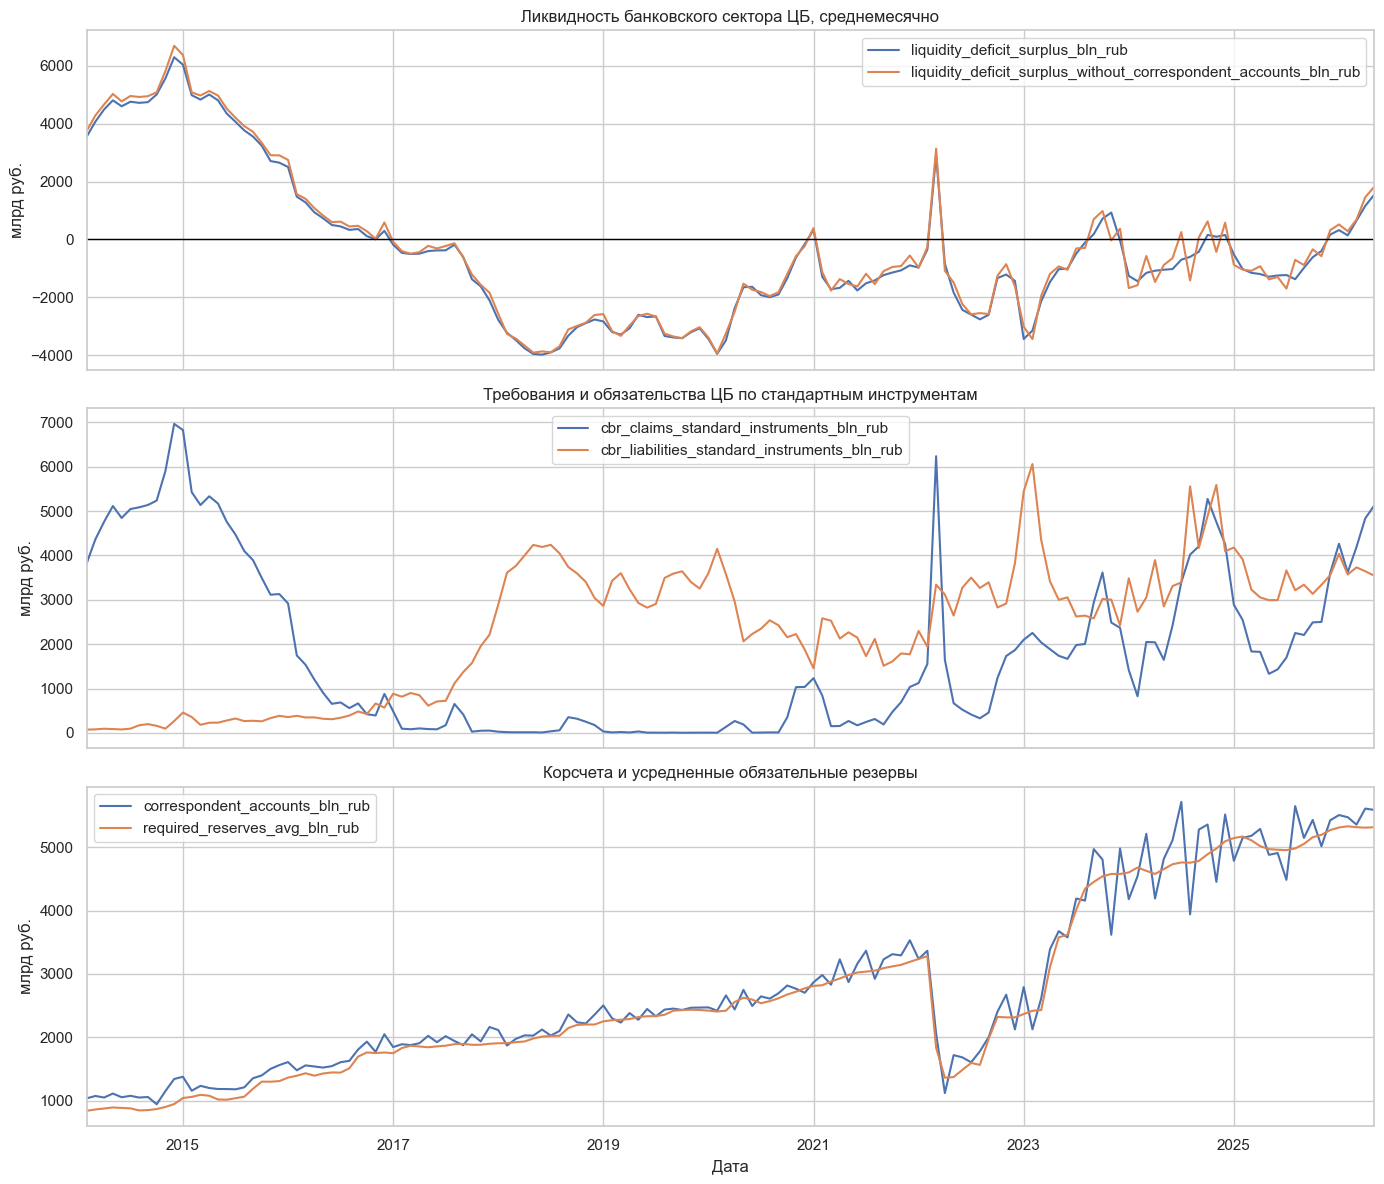

In [26]:
liq_ts = liquidity.set_index("date_dt").sort_index()
liq_monthly = liq_ts.resample("ME").mean(numeric_only=True)

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

liq_monthly[[
    "liquidity_deficit_surplus_bln_rub",
    "liquidity_deficit_surplus_without_correspondent_accounts_bln_rub",
]].plot(ax=axes[0])
axes[0].set_title("Ликвидность банковского сектора ЦБ, среднемесячно")
axes[0].set_ylabel("млрд руб.")
axes[0].axhline(0, color="black", linewidth=1)

liq_monthly[[
    "cbr_claims_standard_instruments_bln_rub",
    "cbr_liabilities_standard_instruments_bln_rub",
]].plot(ax=axes[1])
axes[1].set_title("Требования и обязательства ЦБ по стандартным инструментам")
axes[1].set_ylabel("млрд руб.")

liq_monthly[[
    "correspondent_accounts_bln_rub",
    "required_reserves_avg_bln_rub",
]].plot(ax=axes[2])
axes[2].set_title("Корсчета и усредненные обязательные резервы")
axes[2].set_ylabel("млрд руб.")
axes[2].set_xlabel("Дата")

plt.tight_layout()
plt.show()


In [27]:
liq_features_for_check = [
    "liquidity_deficit_surplus_bln_rub",
    "liquidity_deficit_surplus_without_correspondent_accounts_bln_rub",
    "cbr_claims_standard_instruments_bln_rub",
    "cbr_liabilities_standard_instruments_bln_rub",
    "correspondent_accounts_bln_rub",
    "required_reserves_avg_bln_rub",
]

liq_desc = liq_ts[liq_features_for_check].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T
display(liq_desc)

liq_ts["liquidity_change_1d"] = liq_ts["liquidity_deficit_surplus_bln_rub"].diff()
print("Крупнейшие однодневные изменения дефицита/профицита ликвидности:")
display(liq_ts[["date", "liquidity_deficit_surplus_bln_rub", "liquidity_change_1d"]].sort_values("liquidity_change_1d", key=lambda s: s.abs(), ascending=False).head(15))


,count,mean,std,min,1%,5%,50%,95%,99%,max
liquidity_deficit_surplus_bln_rub,"3,077.0000",-391.1157,"2,512.3147","-4,460.1000","-4,095.4600","-3,624.4400",-927.4000,"4,825.8400","5,867.9720","7,014.3000"
liquidity_deficit_surplus_without_correspondent_accounts_bln_rub,"3,077.0000",-290.2454,"2,618.9976","-5,026.5000","-4,111.9000","-3,588.5400",-820.4000,"5,074.6000","6,334.3480","7,838.5000"
cbr_claims_standard_instruments_bln_rub,"3,077.0000","1,791.3843","1,928.0668",5.1000,5.1000,5.7000,"1,153.3000","5,350.8200","7,136.8920","9,817.0000"
cbr_liabilities_standard_instruments_bln_rub,"3,077.0000","2,358.0807","1,533.7761",52.4000,70.6280,118.7800,"2,702.7000","4,530.1200","6,341.6800","7,751.9000"
correspondent_accounts_bln_rub,"3,077.0000","2,789.4410","1,521.6225",574.8000,851.2960,"1,051.6800","2,380.8000","5,563.8000","6,992.5480","12,127.5000"
required_reserves_avg_bln_rub,"3,077.0000","2,688.5691","1,389.2916",825.8000,846.1000,883.4000,"2,324.4000","5,181.7000","5,315.5000","5,342.2000"


Крупнейшие однодневные изменения дефицита/профицита ликвидности:


,date,liquidity_deficit_surplus_bln_rub,liquidity_change_1d
date_dt,,,
2022-02-28,28-02-2022,"4,216.6000","4,087.7000"
2023-12-29,29-12-2023,"1,320.7000","2,334.8000"
2023-05-02,02-05-2023,500.4000,"1,898.0000"
2023-03-30,30-03-2023,"-1,776.7000","-1,830.6000"
2022-03-10,10-03-2022,"3,715.2000","-1,810.4000"
2023-01-01,01-01-2023,"-3,471.1000","-1,762.1000"
2022-03-01,01-03-2022,"5,846.1000","1,629.5000"
2023-03-29,29-03-2023,53.9000,"1,592.8000"
2024-03-29,29-03-2024,45.4000,"1,386.8000"


## 6. EDA: бюджетные средства ЦБ

`m5_dataset.csv` сейчас использует только `currency_type = total`. Для рублевого денежного рынка это методологически слабее, чем отдельный рублевый ряд: total часто существенно зависит от иностранной валюты и драгоценных металлов.


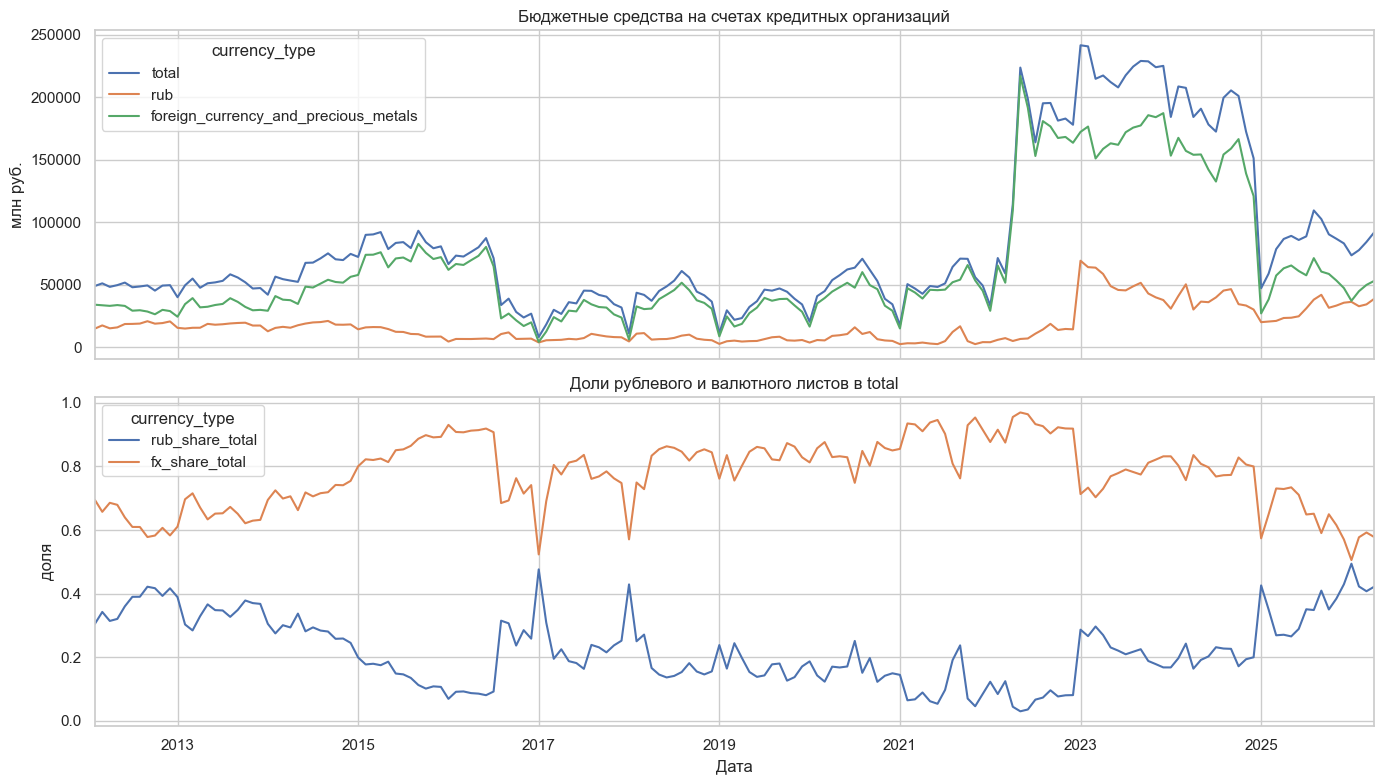

Согласованность total = rub + foreign_currency_and_precious_metals:


currency_type,total,rub,foreign_currency_and_precious_metals,rub_share_total,fx_share_total,sum_diff
count,171.0000,171.0000,171.0000,171.0000,171.0000,171.0000
mean,"83,078.9181","17,286.5614","65,792.3567",0.2217,0.7783,0.0000
std,"61,001.0571","14,142.3883","51,021.9430",0.1067,0.1067,0.4971
min,"8,252.0000","2,553.0000","4,320.0000",0.0300,0.5058,-1.0000
25%,"45,237.0000","6,675.0000","32,384.0000",0.1438,0.7047,0.0000
50%,"57,733.0000","13,889.0000","46,130.0000",0.1999,0.8001,0.0000
75%,"88,024.5000","20,159.0000","71,178.0000",0.2953,0.8562,0.0000
max,"241,474.0000","69,242.0000","216,925.0000",0.4943,0.9700,1.0000


Месяцы с максимальной долей валютного листа:


currency_type,total,rub,foreign_currency_and_precious_metals,rub_share_total,fx_share_total,sum_diff
date_dt,,,,,,
2022-05-01,"223,626.0000","6,701.0000","216,925.0000",0.0300,0.9700,0.0000
2022-06-01,"198,623.0000","7,085.0000","191,537.0000",0.0357,0.9643,1.0000
2022-04-01,"114,477.0000","5,071.0000","109,406.0000",0.0443,0.9557,0.0000
2021-11-01,"56,069.0000","2,572.0000","53,497.0000",0.0459,0.9541,0.0000
2021-06-01,"48,278.0000","2,590.0000","45,688.0000",0.0536,0.9464,0.0000
2021-05-01,"49,024.0000","3,023.0000","46,001.0000",0.0617,0.9383,0.0000
2021-02-01,"50,530.0000","3,264.0000","47,266.0000",0.0646,0.9354,0.0000
2022-07-01,"163,875.0000","10,927.0000","152,949.0000",0.0667,0.9333,-1.0000
2021-03-01,"47,001.0000","3,176.0000","43,824.0000",0.0676,0.9324,1.0000


In [28]:
budget_wide = budget.pivot(index="date_dt", columns="currency_type", values="budget_funds_total_mln_rub").sort_index()
budget_wide["rub_share_total"] = budget_wide["rub"] / budget_wide["total"]
budget_wide["fx_share_total"] = budget_wide["foreign_currency_and_precious_metals"] / budget_wide["total"]
budget_wide["sum_diff"] = budget_wide["total"] - budget_wide["rub"] - budget_wide["foreign_currency_and_precious_metals"]

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
budget_wide[["total", "rub", "foreign_currency_and_precious_metals"]].plot(ax=axes[0])
axes[0].set_title("Бюджетные средства на счетах кредитных организаций")
axes[0].set_ylabel("млн руб.")

budget_wide[["rub_share_total", "fx_share_total"]].plot(ax=axes[1])
axes[1].set_title("Доли рублевого и валютного листов в total")
axes[1].set_ylabel("доля")
axes[1].set_xlabel("Дата")

plt.tight_layout()
plt.show()

print("Согласованность total = rub + foreign_currency_and_precious_metals:")
display(budget_wide[["total", "rub", "foreign_currency_and_precious_metals", "rub_share_total", "fx_share_total", "sum_diff"]].describe())

print("Месяцы с максимальной долей валютного листа:")
display(budget_wide.sort_values("fx_share_total", ascending=False).head(12)[[
    "total", "rub", "foreign_currency_and_precious_metals", "rub_share_total", "fx_share_total", "sum_diff"
]])


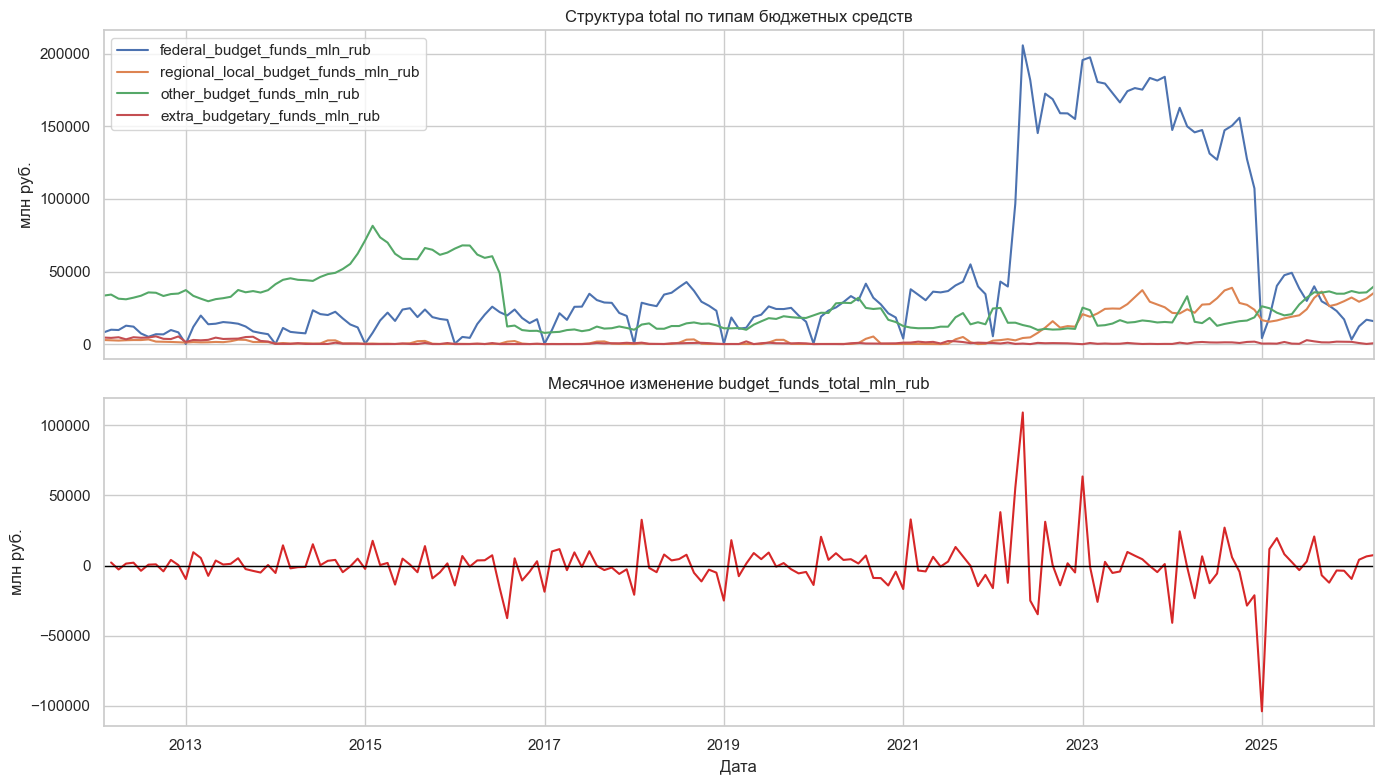

Проверка total против суммы компонент:


,budget_funds_total_mln_rub,components_sum,components_diff
count,171.0000,171.0000,171.0000
mean,"83,078.9181","83,078.9006",0.0175
std,"61,001.0571","61,001.1015",0.5988
min,"8,252.0000","8,251.0000",-2.0000
25%,"45,237.0000","45,236.5000",0.0000
50%,"57,733.0000","57,733.0000",0.0000
75%,"88,024.5000","88,024.5000",0.0000
max,"241,474.0000","241,474.0000",2.0000


In [29]:
budget_total_components = budget[budget["currency_type"] == "total"].set_index("date_dt").sort_index().copy()
component_cols = [
    "federal_budget_funds_mln_rub",
    "regional_local_budget_funds_mln_rub",
    "other_budget_funds_mln_rub",
    "extra_budgetary_funds_mln_rub",
]

budget_total_components["components_sum"] = budget_total_components[component_cols].sum(axis=1)
budget_total_components["components_diff"] = budget_total_components["budget_funds_total_mln_rub"] - budget_total_components["components_sum"]
budget_total_components["budget_total_change"] = budget_total_components["budget_funds_total_mln_rub"].diff()
budget_total_components["budget_total_pct_change"] = budget_total_components["budget_funds_total_mln_rub"].pct_change()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
budget_total_components[component_cols].plot(ax=axes[0])
axes[0].set_title("Структура total по типам бюджетных средств")
axes[0].set_ylabel("млн руб.")

budget_total_components["budget_total_change"].plot(ax=axes[1], color="tab:red")
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("Месячное изменение budget_funds_total_mln_rub")
axes[1].set_ylabel("млн руб.")
axes[1].set_xlabel("Дата")

plt.tight_layout()
plt.show()

print("Проверка total против суммы компонент:")
display(budget_total_components[["budget_funds_total_mln_rub", "components_sum", "components_diff"]].describe())


## 7. EDA: аукционы Росказны

Разделяем три смысла данных Росказны:
- `auction_date`: спрос банков, конкуренция и условия аукциона;
- `first_leg_date`: дата фактического размещения средств в банках, то есть приток ликвидности;
- `second_leg_date`: дата возврата средств, то есть потенциальный отток ликвидности.


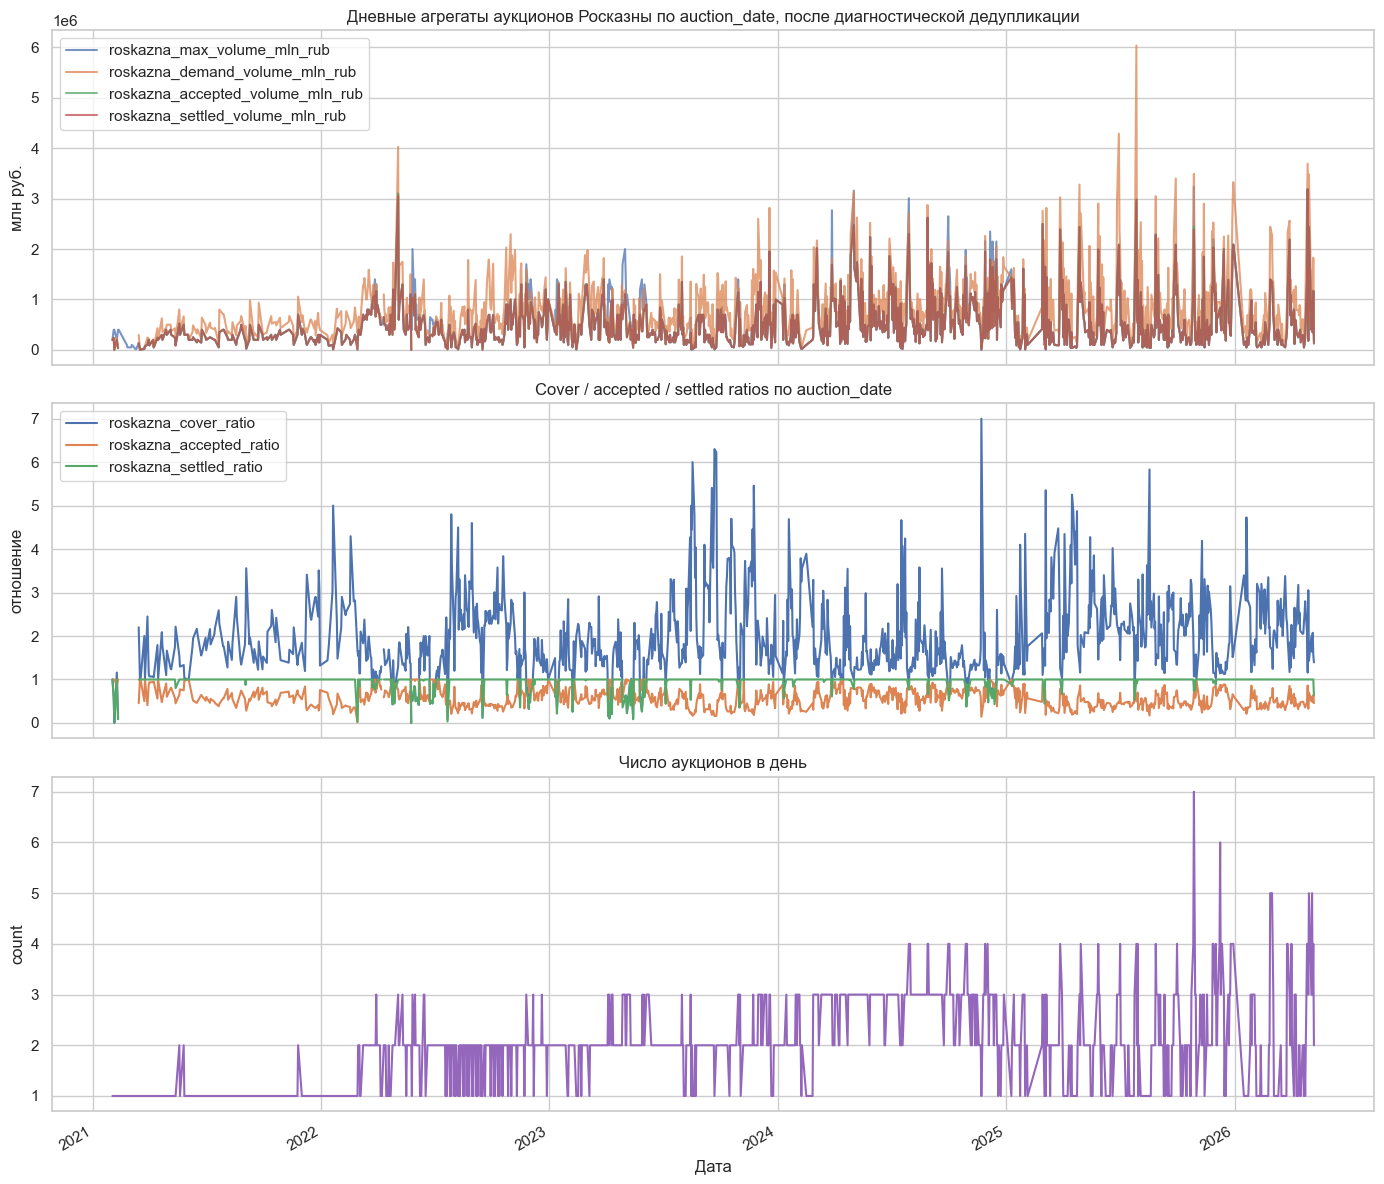

In [30]:
ros_auction_daily = aggregate_roskazna_by_date(roskazna_dedup, "auction_date")
ros_auction_daily["auction_date_dt"] = pd.to_datetime(ros_auction_daily["auction_date"], format=DATE_FORMAT, errors="coerce")
ros_auction_daily = ros_auction_daily.sort_values("auction_date_dt").set_index("auction_date_dt")

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
ros_auction_daily[[
    "roskazna_max_volume_mln_rub",
    "roskazna_demand_volume_mln_rub",
    "roskazna_accepted_volume_mln_rub",
    "roskazna_settled_volume_mln_rub",
]].plot(ax=axes[0], alpha=0.75)
axes[0].set_title("Дневные агрегаты аукционов Росказны по auction_date, после диагностической дедупликации")
axes[0].set_ylabel("млн руб.")

ros_auction_daily[["roskazna_cover_ratio", "roskazna_accepted_ratio", "roskazna_settled_ratio"]].plot(ax=axes[1])
axes[1].set_title("Cover / accepted / settled ratios по auction_date")
axes[1].set_ylabel("отношение")

ros_auction_daily["roskazna_auctions_count"].plot(ax=axes[2], color="tab:purple")
axes[2].set_title("Число аукционов в день")
axes[2].set_ylabel("count")
axes[2].set_xlabel("Дата")

plt.tight_layout()
plt.show()


Ставки и спреды по типам rate_type:


rate_type                                 FIXED  FLOATING
weighted_average_accepted_rate count 1,506.0000  750.0000
                               mean     13.1233    0.6249
                               std       4.8661    0.5582
                               min       4.0500    0.0000
                               25%       7.9625    0.1400
                               50%      14.4200    0.5500
                               75%      16.8000    0.9500
                               max      21.5200    3.1400
min_rate                       count 1,534.0000    0.0000
                               mean     12.8309       NaN
                               std       4.8681       NaN
                               min       4.0500       NaN
                               25%       7.2700       NaN
                               50%      14.3200       NaN
                               75%      16.6600       NaN
                               max      20.0500       NaN
cutoff_rate                    count 1,507.0000  750.0000
                               mean     13.0946    0.5726
                               std       4.8587    0.5558
                               min       4.0500    0.0000
                               25%       7.9300    0.0425
                               50%      14.3500    0.5000
                               75%      16.7900    0.8700
                               max      21.5200    3.1400
min_bid_rate                   count 1,507.0000  750.0000
                               mean     12.9202    0.1509
                               std       4.8472    0.2863
                               min       4.0500    0.0000
                               25%       7.2900    0.0000
                               50%      14.3200    0.0000
                               75%      16.6600    0.1500
                               max      20.6200    1.7700
max_bid_rate                   count 1,507.0000  750.0000
                               mean     13.2054    0.7364
                               std       4.9015    0.7897
                               min       4.0500    0.0000
                               25%       8.0300    0.2600
                               50%      14.4600    0.6750
                               75%      16.9050    1.0375
                               max      26.4000   15.7600

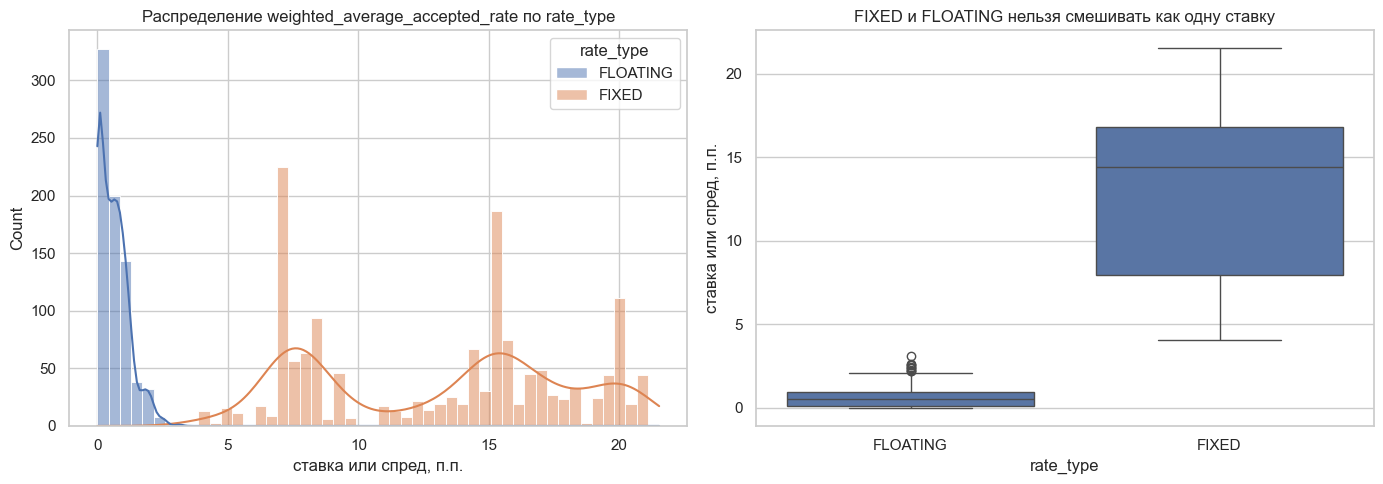

In [31]:
rate_cols = ["weighted_average_accepted_rate", "min_rate", "cutoff_rate", "min_bid_rate", "max_bid_rate"]

print("Ставки и спреды по типам rate_type:")
display(roskazna_dedup.groupby("rate_type")[rate_cols].describe().T)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(data=roskazna_dedup, x="weighted_average_accepted_rate", hue="rate_type", bins=50, kde=True, ax=axes[0])
axes[0].set_title("Распределение weighted_average_accepted_rate по rate_type")
axes[0].set_xlabel("ставка или спред, п.п.")

sns.boxplot(data=roskazna_dedup, x="rate_type", y="weighted_average_accepted_rate", ax=axes[1])
axes[1].set_title("FIXED и FLOATING нельзя смешивать как одну ставку")
axes[1].set_xlabel("rate_type")
axes[1].set_ylabel("ставка или спред, п.п.")

plt.tight_layout()
plt.show()


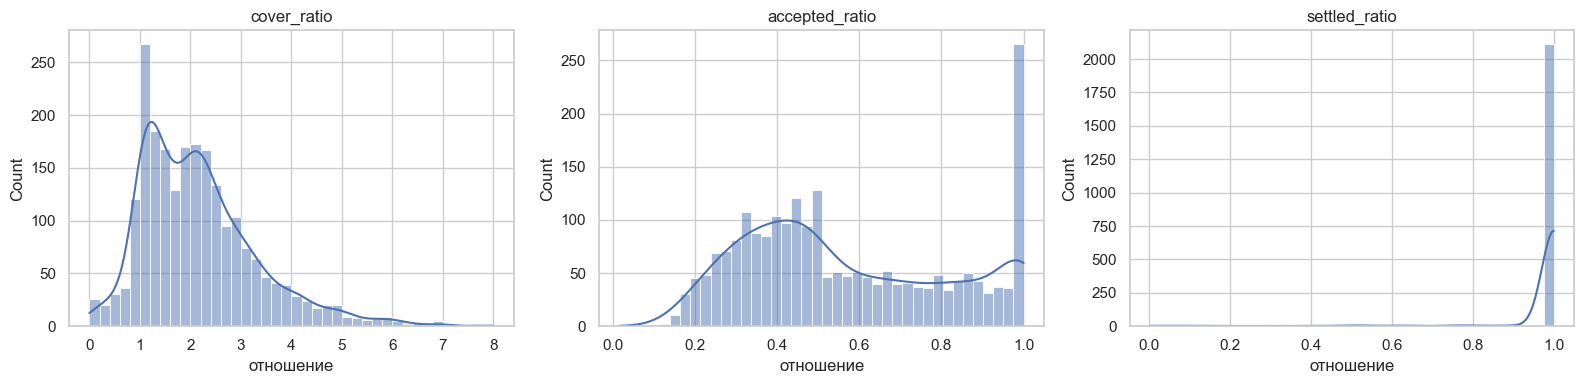

,ratio,min,median,max,missing,gt_1_count
0,cover_ratio,0.0025,2.0000,8.0000,27,2024
1,accepted_ratio,0.0162,0.5000,1.0000,28,0
2,settled_ratio,0.0025,1.0000,1.0000,28,0


In [32]:
ratio_cols = ["cover_ratio", "accepted_ratio", "settled_ratio"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ratio_cols):
    sns.histplot(roskazna_dedup[col], bins=40, kde=True, ax=ax)
    ax.set_title(col)
    ax.set_xlabel("отношение")
plt.tight_layout()
plt.show()

ratio_quality = []
for col in ratio_cols:
    s = roskazna_dedup[col]
    ratio_quality.append({
        "ratio": col,
        "min": s.min(),
        "median": s.median(),
        "max": s.max(),
        "missing": int(s.isna().sum()),
        "gt_1_count": int((s > 1).sum()),
    })

display(pd.DataFrame(ratio_quality))


Периоды с максимальным спросом на депозиты Казначейства:


,auction_date,roskazna_auctions_count,roskazna_max_volume_mln_rub,roskazna_demand_volume_mln_rub,roskazna_accepted_volume_mln_rub,roskazna_settled_volume_mln_rub,roskazna_cover_ratio,roskazna_accepted_ratio,roskazna_weighted_average_rate,roskazna_bidders_count
auction_date_dt,,,,,,,,,,
2025-07-28,28-07-2025,4,"2,980,000.0000","6,035,577.0000","2,980,000.0000","2,980,000.0000",2.0254,0.4937,17.2676,25.0000
2025-06-30,30-06-2025,3,"2,088,000.0000","4,288,805.0000","2,088,000.0000","2,088,000.0000",2.0540,0.4868,14.8100,13.0000
2022-05-04,04-05-2022,3,"3,100,000.0000","4,029,148.0000","3,100,000.0000","3,051,380.0000",1.2997,0.7694,13.7200,12.0000
2026-04-28,28-04-2026,4,"3,188,000.0000","3,694,834.0000","3,188,000.0000","3,188,000.0000",1.1590,0.8628,12.7742,17.0000
2025-10-28,28-10-2025,7,"3,238,000.0000","3,491,138.0000","2,445,365.0000","2,385,365.0000",1.0782,0.7004,3.0462,35.0000
2026-04-30,30-04-2026,5,"2,438,000.0000","3,482,433.0000","2,438,000.0000","2,438,000.0000",1.4284,0.7001,10.4533,24.0000
2025-09-29,29-09-2025,3,"2,088,000.0000","3,399,888.0000","2,088,000.0000","2,088,000.0000",1.6283,0.6141,11.9064,19.0000
2025-12-30,30-12-2025,4,"2,090,000.0000","3,329,596.0000","2,090,000.0000","2,090,000.0000",1.5931,0.6277,0.2258,17.0000
2025-04-28,28-04-2025,3,"2,438,000.0000","3,278,995.0000","2,438,000.0000","2,438,000.0000",1.3450,0.7435,15.9977,14.0000


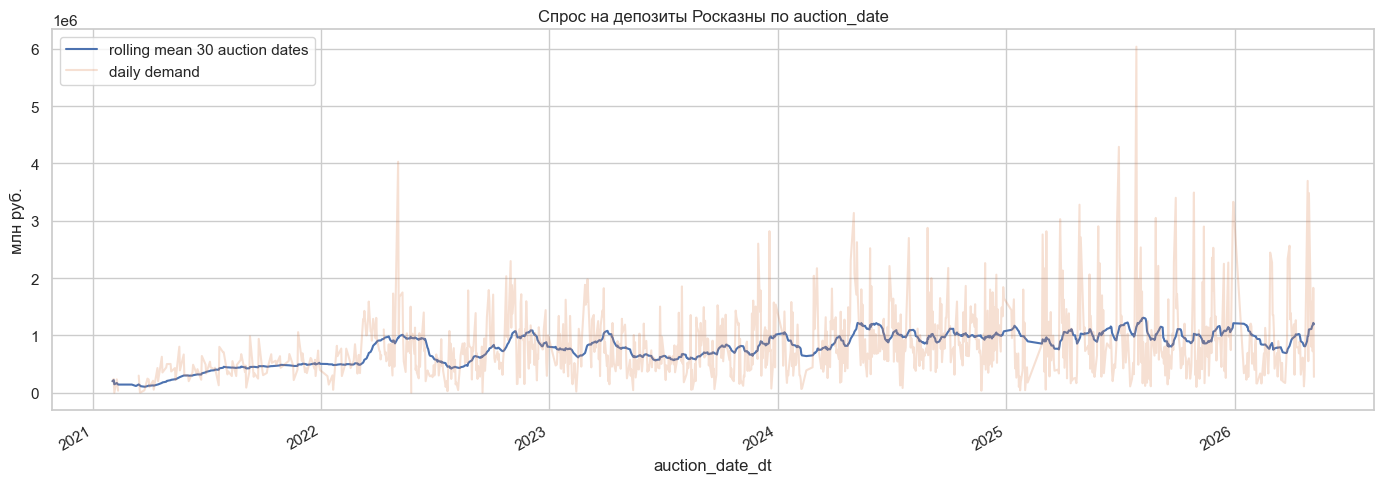

In [33]:
high_demand = ros_auction_daily.copy()
high_demand["demand_rank"] = high_demand["roskazna_demand_volume_mln_rub"].rank(ascending=False, method="min")

print("Периоды с максимальным спросом на депозиты Казначейства:")
display(high_demand.sort_values("roskazna_demand_volume_mln_rub", ascending=False).head(20)[[
    "auction_date",
    "roskazna_auctions_count",
    "roskazna_max_volume_mln_rub",
    "roskazna_demand_volume_mln_rub",
    "roskazna_accepted_volume_mln_rub",
    "roskazna_settled_volume_mln_rub",
    "roskazna_cover_ratio",
    "roskazna_accepted_ratio",
    "roskazna_weighted_average_rate",
    "roskazna_bidders_count",
]])

fig, ax = plt.subplots(figsize=(14, 5))
high_demand["roskazna_demand_volume_mln_rub"].rolling(30, min_periods=1).mean().plot(ax=ax, label="rolling mean 30 auction dates")
high_demand["roskazna_demand_volume_mln_rub"].plot(ax=ax, alpha=0.25, label="daily demand")
ax.set_title("Спрос на депозиты Росказны по auction_date")
ax.set_ylabel("млн руб.")
ax.legend()
plt.tight_layout()
plt.show()


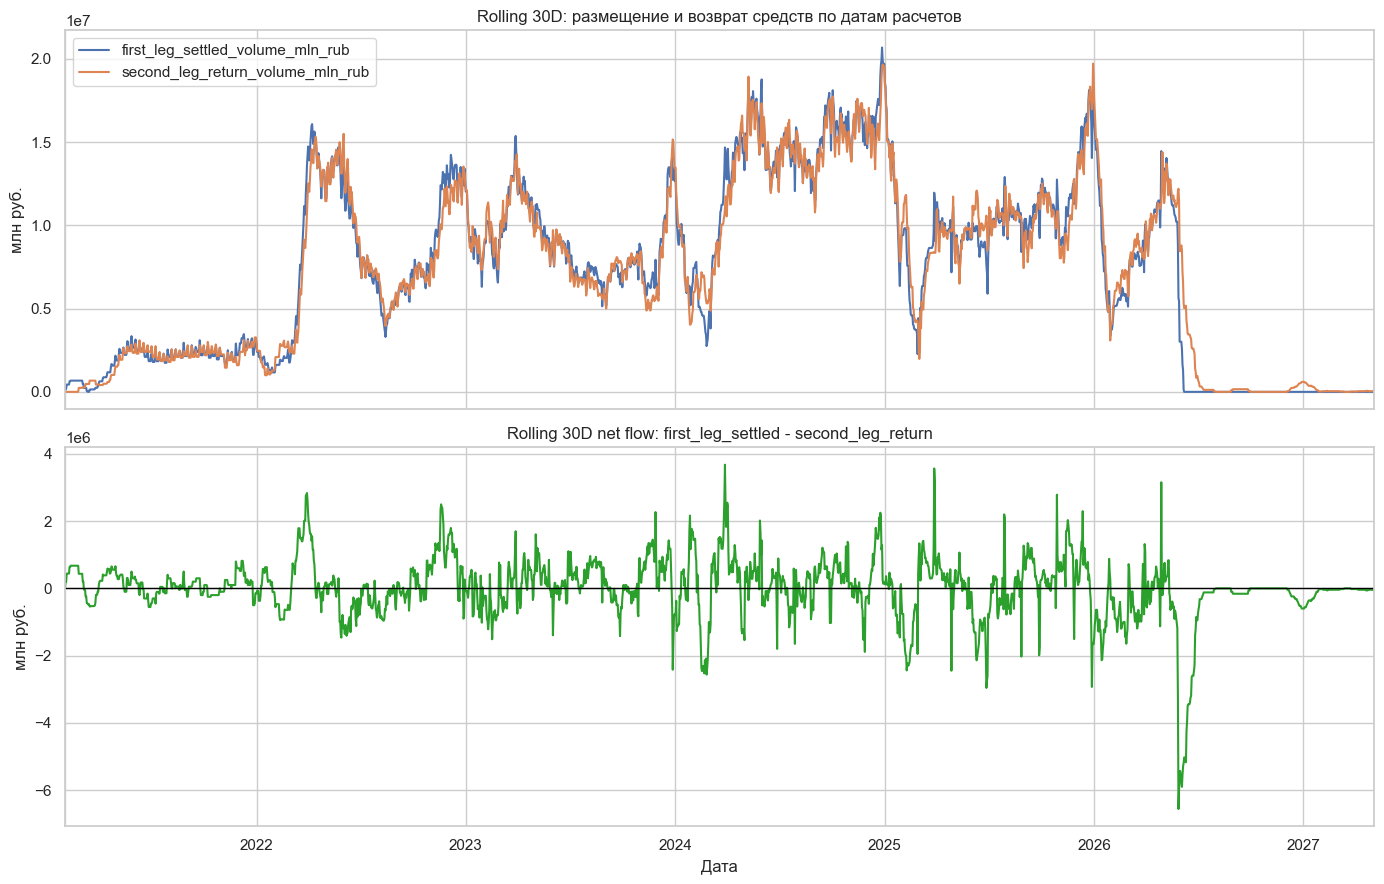

Крупнейшие расчетные притоки по first_leg_date:


,date,first_leg_settled_volume_mln_rub,first_leg_auctions_count,second_leg_return_volume_mln_rub,roskazna_net_flow_by_legs_mln_rub
date_dt,,,,,
2026-04-28,28-04-2026,"3,188,000.0000",4.0000,"50,000.0000","3,138,000.0000"
2025-07-28,28-07-2025,"2,980,000.0000",4.0000,"156,000.0000","2,824,000.0000"
2024-08-28,28-08-2024,"2,620,000.0000",4.0000,"449,000.0000","2,171,000.0000"
2025-02-28,28-02-2025,"2,498,000.0000",3.0000,"20,000.0000","2,478,000.0000"
2024-05-02,02-05-2024,"2,476,463.0000",3.0000,"540,000.0000","1,936,463.0000"
2025-04-28,28-04-2025,"2,438,000.0000",3.0000,"110,000.0000","2,328,000.0000"
2026-04-30,30-04-2026,"2,438,000.0000",5.0000,"3,038,000.0000","-600,000.0000"
2025-03-28,28-03-2025,"2,390,000.0000",4.0000,"60,000.0000","2,330,000.0000"
2025-10-28,28-10-2025,"2,385,365.0000",7.0000,"58,000.0000","2,327,365.0000"


Крупнейшие возвраты по second_leg_date:


,date,first_leg_settled_volume_mln_rub,second_leg_return_volume_mln_rub,second_leg_auctions_count,roskazna_net_flow_by_legs_mln_rub
date_dt,,,,,
2026-04-30,30-04-2026,"2,438,000.0000","3,038,000.0000",4.0000,"-600,000.0000"
2022-05-04,04-05-2022,"2,351,380.0000","2,794,727.0000",5.0000,"-443,347.0000"
2025-03-04,04-03-2025,"1,650,000.0000","2,468,000.0000",3.0000,"-818,000.0000"
2024-05-08,08-05-2024,"1,840,000.0000","2,240,000.0000",2.0000,"-400,000.0000"
2024-05-30,30-05-2024,"1,550,000.0000","2,220,000.0000",2.0000,"-670,000.0000"
2023-12-19,19-12-2023,"1,950,000.0000","2,100,000.0000",4.0000,"-150,000.0000"
2025-12-30,30-12-2025,"2,090,000.0000","2,030,000.0000",4.0000,"60,000.0000"
2024-04-11,11-04-2024,"1,320,000.0000","1,990,000.0000",2.0000,"-670,000.0000"
2025-04-30,30-04-2025,"1,340,000.0000","1,978,000.0000",4.0000,"-638,000.0000"


In [34]:
first_leg_daily = aggregate_roskazna_by_date(roskazna_dedup, "first_leg_date").rename(columns={
    "first_leg_date": "date",
    "roskazna_settled_volume_mln_rub": "first_leg_settled_volume_mln_rub",
    "roskazna_accepted_volume_mln_rub": "first_leg_accepted_volume_mln_rub",
    "roskazna_auctions_count": "first_leg_auctions_count",
})
second_leg_daily = aggregate_roskazna_by_date(roskazna_dedup, "second_leg_date").rename(columns={
    "second_leg_date": "date",
    "roskazna_settled_volume_mln_rub": "second_leg_return_volume_mln_rub",
    "roskazna_accepted_volume_mln_rub": "second_leg_accepted_volume_mln_rub",
    "roskazna_auctions_count": "second_leg_auctions_count",
})

flow = pd.DataFrame({"date_dt": pd.date_range(roskazna["auction_date_dt"].min(), roskazna["second_leg_date_dt"].max(), freq="D")})
flow["date"] = flow["date_dt"].dt.strftime(DATE_FORMAT)
flow = flow.merge(first_leg_daily[["date", "first_leg_settled_volume_mln_rub", "first_leg_auctions_count"]], on="date", how="left")
flow = flow.merge(second_leg_daily[["date", "second_leg_return_volume_mln_rub", "second_leg_auctions_count"]], on="date", how="left")
flow[["first_leg_settled_volume_mln_rub", "first_leg_auctions_count", "second_leg_return_volume_mln_rub", "second_leg_auctions_count"]] = flow[[
    "first_leg_settled_volume_mln_rub", "first_leg_auctions_count", "second_leg_return_volume_mln_rub", "second_leg_auctions_count"
]].fillna(0)
flow["roskazna_net_flow_by_legs_mln_rub"] = flow["first_leg_settled_volume_mln_rub"] - flow["second_leg_return_volume_mln_rub"]
flow = flow.set_index("date_dt").sort_index()

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
flow[["first_leg_settled_volume_mln_rub", "second_leg_return_volume_mln_rub"]].rolling(30, min_periods=1).sum().plot(ax=axes[0])
axes[0].set_title("Rolling 30D: размещение и возврат средств по датам расчетов")
axes[0].set_ylabel("млн руб.")

flow["roskazna_net_flow_by_legs_mln_rub"].rolling(30, min_periods=1).sum().plot(ax=axes[1], color="tab:green")
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("Rolling 30D net flow: first_leg_settled - second_leg_return")
axes[1].set_ylabel("млн руб.")
axes[1].set_xlabel("Дата")

plt.tight_layout()
plt.show()

print("Крупнейшие расчетные притоки по first_leg_date:")
display(flow.sort_values("first_leg_settled_volume_mln_rub", ascending=False).head(15)[[
    "date", "first_leg_settled_volume_mln_rub", "first_leg_auctions_count", "second_leg_return_volume_mln_rub", "roskazna_net_flow_by_legs_mln_rub"
]])

print("Крупнейшие возвраты по second_leg_date:")
display(flow.sort_values("second_leg_return_volume_mln_rub", ascending=False).head(15)[[
    "date", "first_leg_settled_volume_mln_rub", "second_leg_return_volume_mln_rub", "second_leg_auctions_count", "roskazna_net_flow_by_legs_mln_rub"
]])


In [35]:
auction_vs_first = (
    aggregate_roskazna_by_date(roskazna_dedup, "auction_date")[["auction_date", "roskazna_settled_volume_mln_rub"]]
    .rename(columns={"auction_date": "date", "roskazna_settled_volume_mln_rub": "settled_by_auction_date"})
    .merge(
        aggregate_roskazna_by_date(roskazna_dedup, "first_leg_date")[["first_leg_date", "roskazna_settled_volume_mln_rub"]]
        .rename(columns={"first_leg_date": "date", "roskazna_settled_volume_mln_rub": "settled_by_first_leg_date"}),
        on="date",
        how="outer",
    )
    .fillna(0)
)
auction_vs_first["abs_diff"] = (auction_vs_first["settled_by_auction_date"] - auction_vs_first["settled_by_first_leg_date"]).abs()

print("Насколько отличается агрегация settled по auction_date и first_leg_date:")
display(pd.DataFrame([
    {"metric": "dates compared", "value": len(auction_vs_first)},
    {"metric": "dates with non-zero difference", "value": int((auction_vs_first["abs_diff"] > 0).sum())},
    {"metric": "max abs daily difference, mln rub", "value": auction_vs_first["abs_diff"].max()},
]))

display(auction_vs_first.sort_values("abs_diff", ascending=False).head(20))


Насколько отличается агрегация settled по auction_date и first_leg_date:


,metric,value
0,dates compared,"1,160.0000"
1,dates with non-zero difference,663.0000
2,"max abs daily difference, mln rub","1,100,000.0000"


,date,settled_by_auction_date,settled_by_first_leg_date,abs_diff
1103,30-01-2023,"200,000.0000","1,300,000.0000","1,100,000.0000"
979,27-01-2023,"1,350,000.0000","250,000.0000","1,100,000.0000"
185,06-02-2023,"200,000.0000","1,150,000.0000","950,000.0000"
76,03-02-2023,"1,100,000.0000","200,000.0000","900,000.0000"
948,26-04-2022,"1,200,000.0000","400,000.0000","800,000.0000"
1041,28-06-2023,"700,000.0000","1,400,000.0000","700,000.0000"
971,26-11-2021,0.0000,"700,000.0000","700,000.0000"
81,03-03-2023,"1,100,000.0000","400,000.0000","700,000.0000"
1033,28-04-2022,"400,000.0000","1,100,000.0000","700,000.0000"
927,25-10-2022,"511,000.0000","1,211,000.0000","700,000.0000"


### Экономический вывод по EDA Росказны

Поля, связанные со спросом (`demand_volume_mln_rub`, `cover_ratio`, `bidders_count`), описывают конкуренцию банков за средства Казначейства и могут отражать напряженность фондирования. Но эти факты известны после торгов, поэтому для same-day модели их лучше лагировать минимум на 1 день.

Поля, связанные с размещением (`accepted_volume_mln_rub`, `settled_volume_mln_rub`), не равны притоку ликвидности в день `auction_date`. Для ликвидности банковского сектора сильнее экономически интерпретируются признаки по `first_leg_date` и `second_leg_date`.

`weighted_average_accepted_rate` нельзя использовать как единую рыночную ставку без разбиения `rate_type`: для `FIXED` это ставка, для `FLOATING` часто спред к базовой плавающей ставке. Смешивание этих значений в одном дневном weighted average экономически слабое.


## 8. Проверка leakage и доступности признаков

Основной вопрос для feature builder: что было известно на момент прогноза. Здесь нет календаря публикаций ЦБ и точного внутридневного cutoff модели, поэтому рекомендации консервативные.


In [36]:
feature_recommendations = pd.DataFrame([
    {
        "feature": "liquidity_deficit_surplus_bln_rub_lag_1d",
        "economic_meaning": "инерция структурного дефицита/профицита ликвидности",
        "source_columns": "m5.liquidity_deficit_surplus_bln_rub",
        "granularity": "daily",
        "leakage_risk": "низкий при shift(1); без лага зависит от постановки target",
        "backend": "рекомендовано",
    },
    {
        "feature": "liquidity_deficit_surplus_bln_rub_change_1d_5d",
        "economic_meaning": "скорость изменения ликвидности, возможный фон стресса",
        "source_columns": "m5.liquidity_deficit_surplus_bln_rub",
        "granularity": "daily",
        "leakage_risk": "использовать только прошлые значения",
        "backend": "рекомендовано",
    },
    {
        "feature": "budget_funds_total_mln_rub_change / pct_change",
        "economic_meaning": "месячное изменение бюджетных остатков на счетах банков",
        "source_columns": "cbr_budget_funds total или m5 budget_funds_total_mln_rub",
        "granularity": "monthly -> daily as-of",
        "leakage_risk": "средний: нужен лаг публикации ЦБ; без него возможен publication leakage",
        "backend": "после согласования календаря публикаций или консервативного лага",
    },
    {
        "feature": "budget_funds_rub_mln_rub_level/change",
        "economic_meaning": "рублевые бюджетные средства ближе к рублевому денежному рынку, чем total",
        "source_columns": "cbr_budget_funds currency_type=rub",
        "granularity": "monthly -> daily as-of",
        "leakage_risk": "такой же, как у total: нужен publication lag",
        "backend": "рекомендовано добавить в dataset/builder после обсуждения",
    },
    {
        "feature": "roskazna_auction_day_flag",
        "economic_meaning": "день отбора средств Казначейства, событие спроса банков",
        "source_columns": "roskazna.auction_date",
        "granularity": "auction-level -> daily",
        "leakage_risk": "низкий для календаря аукционов; результаты аукциона не включать без лага",
        "backend": "рекомендовано",
    },
    {
        "feature": "roskazna_demand_volume_lag_1d / cover_ratio_lag_1d",
        "economic_meaning": "напряженность спроса банков на казначейские депозиты",
        "source_columns": "demand_volume_mln_rub, max_volume_mln_rub",
        "granularity": "auction_date daily aggregation",
        "leakage_risk": "результат торгов, для same-day target лагировать минимум на 1 день",
        "backend": "рекомендовано с лагом",
    },
    {
        "feature": "roskazna_first_leg_settled_volume_mln_rub",
        "economic_meaning": "фактический приток средств Казначейства в банки",
        "source_columns": "first_leg_date, settled_volume_mln_rub",
        "granularity": "auction-level -> daily by first_leg_date",
        "leakage_risk": "средний для same-day first_leg; нужен cutoff: было ли известно до прогноза",
        "backend": "рекомендовано как отдельный flow-признак",
    },
    {
        "feature": "roskazna_second_leg_return_volume_mln_rub",
        "economic_meaning": "возврат депозитов Казначейству, потенциальный отток ликвидности из банков",
        "source_columns": "second_leg_date, settled_volume_mln_rub",
        "granularity": "auction-level -> daily by second_leg_date",
        "leakage_risk": "низкий, если дата возврата известна из ранее прошедшего аукциона; нельзя использовать будущие еще не объявленные аукционы",
        "backend": "рекомендовано",
    },
    {
        "feature": "roskazna_net_flow_by_legs_mln_rub",
        "economic_meaning": "чистый расчетный эффект Казначейства: размещение минус возврат",
        "source_columns": "first_leg_date, second_leg_date, settled_volume_mln_rub",
        "granularity": "daily",
        "leakage_risk": "строить только из аукционов, известных на дату прогноза",
        "backend": "рекомендовано после уточнения cutoff",
    },
    {
        "feature": "rolling_sum_roskazna_flows_7_14_30d",
        "economic_meaning": "накопленный фискальный приток/отток за последние недели",
        "source_columns": "settled by first_leg/second_leg",
        "granularity": "daily rolling",
        "leakage_risk": "rolling должен быть backward-looking и с нужным shift",
        "backend": "рекомендовано",
    },
    {
        "feature": "days_since_last_roskazna_auction",
        "economic_meaning": "давность последнего события Казначейства",
        "source_columns": "auction_date",
        "granularity": "daily",
        "leakage_risk": "низкий",
        "backend": "рекомендовано",
    },
    {
        "feature": "days_to_next_known_roskazna_settlement",
        "economic_meaning": "ожидаемый ближайший приток по уже известным аукционам",
        "source_columns": "first_leg_date, auction publication/result date",
        "granularity": "daily",
        "leakage_risk": "высокий, если брать все будущие first_leg_date из полного датасета",
        "backend": "только после строгого point-in-time правила",
    },
    {
        "feature": "roskazna_weighted_average_rate raw",
        "economic_meaning": "условия размещения средств",
        "source_columns": "weighted_average_accepted_rate, rate_type, base_floating_rate",
        "granularity": "auction_date daily aggregation",
        "leakage_risk": "результат торгов; кроме того FIXED и FLOATING имеют разный смысл",
        "backend": "не переносить в сыром смешанном виде",
    },
])

display(feature_recommendations)


,feature,economic_meaning,source_columns,granularity,leakage_risk,backend
0,liquidity_deficit_surplus_bln_rub_lag_1d,инерция структурного дефицита/профицита ликвид...,m5.liquidity_deficit_surplus_bln_rub,daily,низкий при shift(1); без лага зависит от поста...,рекомендовано
1,liquidity_deficit_surplus_bln_rub_change_1d_5d,"скорость изменения ликвидности, возможный фон ...",m5.liquidity_deficit_surplus_bln_rub,daily,использовать только прошлые значения,рекомендовано
2,budget_funds_total_mln_rub_change / pct_change,месячное изменение бюджетных остатков на счета...,cbr_budget_funds total или m5 budget_funds_tot...,monthly -> daily as-of,средний: нужен лаг публикации ЦБ; без него воз...,после согласования календаря публикаций или ко...
3,budget_funds_rub_mln_rub_level/change,рублевые бюджетные средства ближе к рублевому ...,cbr_budget_funds currency_type=rub,monthly -> daily as-of,"такой же, как у total: нужен publication lag",рекомендовано добавить в dataset/builder после...
4,roskazna_auction_day_flag,"день отбора средств Казначейства, событие спро...",roskazna.auction_date,auction-level -> daily,низкий для календаря аукционов; результаты аук...,рекомендовано
5,roskazna_demand_volume_lag_1d / cover_ratio_la...,напряженность спроса банков на казначейские де...,"demand_volume_mln_rub, max_volume_mln_rub",auction_date daily aggregation,"результат торгов, для same-day target лагирова...",рекомендовано с лагом
6,roskazna_first_leg_settled_volume_mln_rub,фактический приток средств Казначейства в банки,"first_leg_date, settled_volume_mln_rub",auction-level -> daily by first_leg_date,средний для same-day first_leg; нужен cutoff: ...,рекомендовано как отдельный flow-признак
7,roskazna_second_leg_return_volume_mln_rub,"возврат депозитов Казначейству, потенциальный ...","second_leg_date, settled_volume_mln_rub",auction-level -> daily by second_leg_date,"низкий, если дата возврата известна из ранее п...",рекомендовано
8,roskazna_net_flow_by_legs_mln_rub,чистый расчетный эффект Казначейства: размещен...,"first_leg_date, second_leg_date, settled_volum...",daily,"строить только из аукционов, известных на дату...",рекомендовано после уточнения cutoff
9,rolling_sum_roskazna_flows_7_14_30d,накопленный фискальный приток/отток за последн...,settled by first_leg/second_leg,daily rolling,rolling должен быть backward-looking и с нужны...,рекомендовано


## 9. Что считать техническим и не переносить напрямую

Не рекомендовано напрямую использовать в модели:
- `auction_id`, `source_file`, `source_url` - технические идентификаторы;
- `bidding_time`, `prediction_time`, `conclusion_time`, `registry_time`, `cutoff_time`, `pay_time` - техническое расписание процедуры, не первичный экономический сигнал;
- `place`, `order_form`, `min_order_mln_rub`, `max_orders_per_bank`, `random_time_seconds`, `netting`, `comment` - либо технические поля, либо слабый/нестабильный сигнал для стресс-модели;
- сырой `roskazna_weighted_average_rate` без разделения `FIXED` и `FLOATING`;
- full-sample z-score любых признаков, если статистика рассчитана на всем датасете. Z-score допустим только rolling/expanding по прошлому окну.

Поля, которые могут быть полезны после методологической обработки:
- `rate_type`, `base_floating_rate`, `min_spread`, `cutoff_rate`, `weighted_average_accepted_rate` - для отдельных fixed-rate и floating-spread признаков;
- `term_days`, `deposit_type` - для разделения коротких, средних и длинных размещений;
- `first_leg_date`, `second_leg_date` - обязательны для flow-признаков.


## 10. Итоговые рекомендации для будущего `m5_feature_builder.py`

Проблема: в текущем source Росказны есть дубли `auction_id`. Почему важно: дневные агрегаты завышают объемы и count на отдельных датах. Как исправить: добавить дедупликацию перед агрегацией, предпочитая строки с заполненными результатами торгов; сохранить диагностический отчет по удаленным дублям.

Проблема: current `m5_dataset.csv` агрегирует Росказну только по `auction_date`. Почему важно: `auction_date` отражает спрос и условия, а не фактическое движение денег. Как исправить: оставить auction-date признаки спроса, но добавить отдельные daily flow-признаки по `first_leg_date` и `second_leg_date`.

Проблема: `budget_funds_total_mln_rub` может быть publication leakage. Почему важно: месячный факт на 1-е число мог быть опубликован позже. Как исправить: до появления календаря публикаций использовать консервативный лаг месячных budget-признаков; в документации явно описать point-in-time допущение.

Проблема: `total` бюджетных средств смешивает рубли и валюту/драгметаллы. Почему важно: задача про рублевый денежный рынок, а total в отдельные периоды почти полностью формируется валютным листом. Как исправить: добавить в базовый dataset или feature builder отдельные рублевые показатели из `currency_type = rub`; total оставить как дополнительный фон.

Проблема: `weighted_average_accepted_rate` смешивает фиксированные ставки и плавающие спреды. Почему важно: агрегированный показатель теряет экономический смысл. Как исправить: считать separate features для `rate_type = FIXED` и `rate_type = FLOATING`; для floating желательно строить spread-to-keyrate/RUONIA только после корректного присоединения ставки из М2.

Рекомендуемый минимальный feature set после согласования:
- lagged liquidity level/change: `liquidity_deficit_surplus_bln_rub_lag_1d`, `change_1d`, `change_5d`;
- budget monthly features с publication lag: level/change/pct_change для total и желательно rub-only;
- auction demand features с лагом: `auction_day_flag`, `demand_volume_lag_1d`, `cover_ratio_lag_1d`, `bidders_count_lag_1d`;
- treasury flow features по датам расчетов: first-leg inflow, second-leg return, net flow, rolling sums 7/14/30 дней;
- event distance: `days_since_last_roskazna_auction`; `days_to_next_known_*` только при строгом point-in-time построении.
